In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set seaborn style
sns.set_theme(style="whitegrid")

# Load data from real_second folder
data_dir = Path('real_second')
datasets = {
    'Base Linux': data_dir / 'base_linux' / 'unikernel_output.csv',
    'Base Unikernel': data_dir / 'base_unikernel' / 'unikernel_output.csv',
    'Optimized Linux (with iso)': data_dir / 'optimized_linux_withiso' / 'unikernel_output.csv',
    'Optimized Linux (no iso)': data_dir / 'optimized_linux_withuotiso' / 'unikernel_output.csv',
    'Optimized Unikernel': data_dir / 'optimized_unikernel' / 'unikernel_output.csv'
}

# Read all datasets
dfs = {}
for name, path in datasets.items():
    if path.exists():
        df = pd.read_csv(path)
        df['source'] = name
        dfs[name] = df
        print(f"Loaded {name}: {len(df)} rows")
    else:
        print(f"Warning: {path} not found")

# Combine all data
all_data = pd.concat(dfs.values(), ignore_index=True)

# Remove rows with NaN benchmarks
all_data = all_data[all_data['benchmark'].notna()]

print("\nUnique benchmarks:", all_data['benchmark'].unique())
print("\nData shape:", all_data.shape)
print("\nSamples per benchmark and source:")
print(all_data.groupby(['benchmark', 'source']).size().unstack(fill_value=0))

Loaded Base Linux: 450 rows
Loaded Base Unikernel: 450 rows
Loaded Optimized Linux (with iso): 450 rows
Loaded Optimized Linux (no iso): 450 rows
Loaded Optimized Unikernel: 450 rows

Unique benchmarks: ['crc32' 'cubic' 'dijkstra' 'fdct' 'fir' 'matmult-float' 'matmult-int'
 'nettle-sha256' 'rijndael']

Data shape: (2250, 22)

Samples per benchmark and source:
source         Base Linux  Base Unikernel  Optimized Linux (no iso)  \
benchmark                                                             
crc32                  50              50                        50   
cubic                  50              50                        50   
dijkstra               50              50                        50   
fdct                   50              50                        50   
fir                    50              50                        50   
matmult-float          50              50                        50   
matmult-int            50              50                        50   

In [3]:
# Define variables for plotting
all_benchmarks = all_data['benchmark'].unique().tolist()
hue_order = ['Base Linux', 'Optimized Linux (with iso)', 'Optimized Linux (no iso)', 'Base Unikernel', 'Optimized Unikernel']
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728']

print(f"All benchmarks: {all_benchmarks}")
print(f"Configuration order: {hue_order}")
print(f"Color palette: {palette}")

All benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
Configuration order: ['Base Linux', 'Optimized Linux (with iso)', 'Optimized Linux (no iso)', 'Base Unikernel', 'Optimized Unikernel']
Color palette: ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728']


# Coefficient of Variation Analysis

In [4]:
# Calculate coefficient of variation (CV = std/mean * 100) for all benchmarks and sources
cv_data = []
for benchmark in all_benchmarks:
    benchmark_data = all_data[all_data['benchmark'] == benchmark]
    row = {'Benchmark': benchmark}
    for source in hue_order:
        source_data = benchmark_data[benchmark_data['source'] == source]['pkg_joules']
        if len(source_data) > 0:
            mean = source_data.mean()
            std = source_data.std()
            cv = (std / mean * 100) if mean != 0 else np.nan
            row[source] = cv
        else:
            row[source] = np.nan
    cv_data.append(row)

# Create DataFrame and display
cv_df = pd.DataFrame(cv_data)
cv_df = cv_df.set_index('Benchmark')

print("Coefficient of Variation (Std/Mean * 100) of Energy by Benchmark and Configuration (%)")
print("=" * 120)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
display(cv_df)

Coefficient of Variation (Std/Mean * 100) of Energy by Benchmark and Configuration (%)


,Base Linux,Optimized Linux (with iso),Optimized Linux (no iso),Base Unikernel,Optimized Unikernel
Benchmark,,,,,
crc32,20.1492,2.9307,0.6901,0.0725,0.0873
cubic,0.0912,2.7181,0.0824,0.0644,0.0446
dijkstra,0.1734,2.3421,0.1231,0.1571,0.1043
fdct,0.5845,3.0994,0.0679,0.0454,0.0730
fir,0.0601,3.4648,0.0917,0.0458,0.0656
matmult-float,0.0821,3.2587,0.0831,0.0649,0.0712
matmult-int,0.5772,3.2001,0.3682,0.0892,0.0853
nettle-sha256,0.0651,2.3325,0.0703,0.0400,0.0368
rijndael,0.0671,2.4158,0.0685,0.0390,0.0498


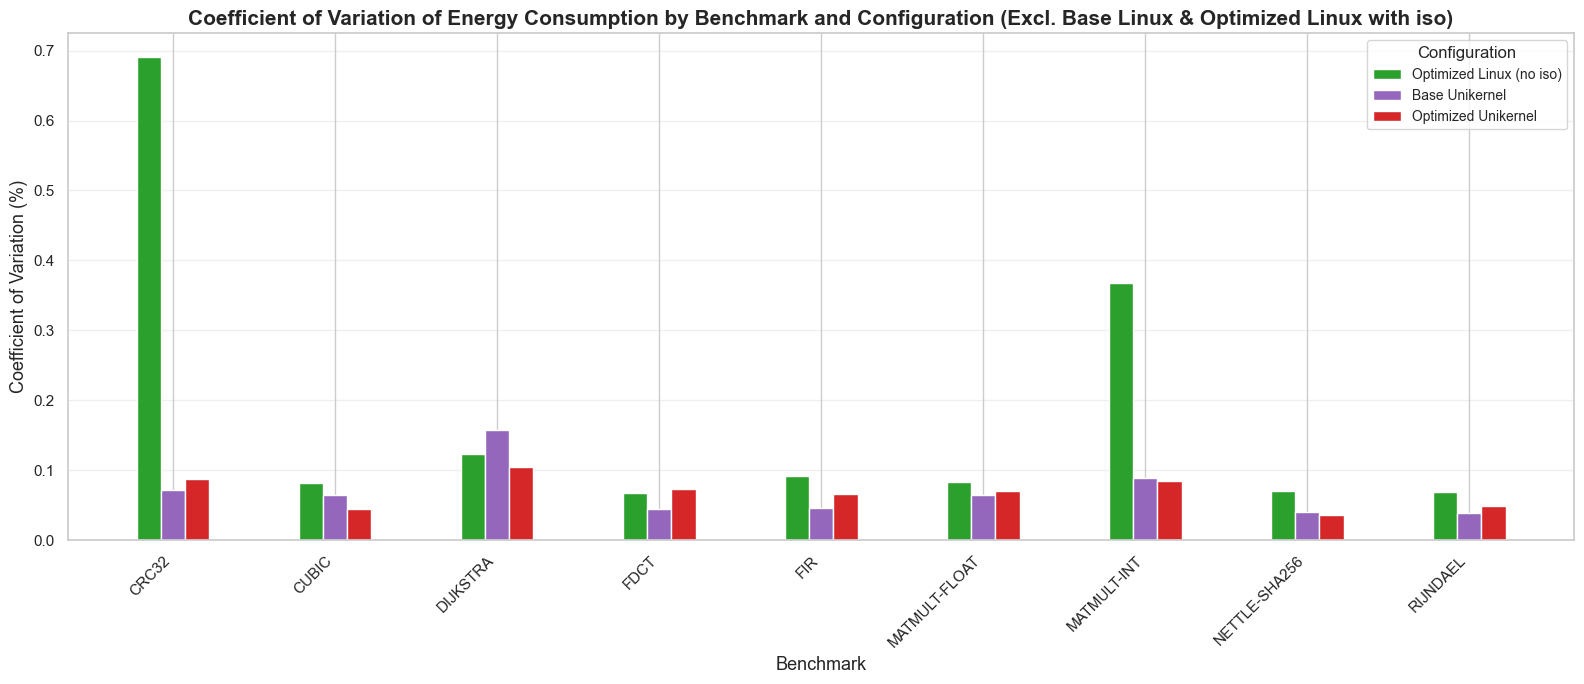

In [5]:
# Exclude 'Base Linux' and 'Optimized Linux (with iso)' from the plot
exclude = ['Base Linux', 'Optimized Linux (with iso)']
filtered_hue_order = [c for c in hue_order if c not in exclude]
filtered_palette = [color for c, color in zip(hue_order, palette) if c not in exclude]

fig, ax = plt.subplots(figsize=(16, 7))

# Prepare data for plotting
cv_melted = cv_df.reset_index().melt(id_vars='Benchmark', var_name='Configuration', value_name='CV')

# Set up bar positions
x = np.arange(len(cv_df.index))
width = 0.15  # Width of each bar
offsets = [i * width - (width * (len(filtered_hue_order)-1)/2) for i in range(len(filtered_hue_order))]

# Plot bars for each configuration (excluding the unwanted ones)
for i, (source, color) in enumerate(zip(filtered_hue_order, filtered_palette)):
    config_data = cv_melted[cv_melted['Configuration'] == source]
    # Ensure data is in the same order as cv_df.index
    cvs = [config_data[config_data['Benchmark'] == b]['CV'].values[0] if not config_data[config_data['Benchmark'] == b].empty else np.nan for b in cv_df.index]
    ax.bar(x + offsets[i], cvs, width, label=source, color=color)

ax.set_xlabel('Benchmark', fontsize=13)
ax.set_ylabel('Coefficient of Variation (%)', fontsize=13)
ax.set_title('Coefficient of Variation of Energy Consumption by Benchmark and Configuration (Excl. Base Linux & Optimized Linux with iso)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(b).upper() for b in cv_df.index], rotation=45, ha='right')
ax.legend(title='Configuration', loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cv_energy_comparison_filtered.png', dpi=150, bbox_inches='tight')
plt.show()

# Mean Energy Consumption Analysis

In [6]:
# Calculate mean and std for energy consumption
mean_data = []
for benchmark in all_benchmarks:
    benchmark_data = all_data[all_data['benchmark'] == benchmark]
    row = {'Benchmark': benchmark}
    for source in hue_order:
        source_data = benchmark_data[benchmark_data['source'] == source]['total_mJ']
        if len(source_data) > 0:
            mean = source_data.mean()
            row[source] = mean
        else:
            row[source] = np.nan
    mean_data.append(row)

# Create DataFrame and display
mean_df = pd.DataFrame(mean_data)
mean_df = mean_df.set_index('Benchmark')

print("Mean Energy Consumption (mJ) by Benchmark and Configuration")
print("=" * 120)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
display(mean_df)

Mean Energy Consumption (mJ) by Benchmark and Configuration


,Base Linux,Optimized Linux (with iso),Optimized Linux (no iso),Base Unikernel,Optimized Unikernel
Benchmark,,,,,
crc32,328745.85,301726.69,262707.42,467395.41,465826.24
cubic,303501.44,299847.51,264220.30,404317.49,403363.11
dijkstra,364126.38,358752.19,318074.14,574580.53,572378.22
fdct,292324.11,287968.92,254400.21,458899.90,457713.70
fir,249244.44,246435.44,217259.77,390180.30,389682.77
matmult-float,334835.89,326558.04,291355.68,523421.70,523581.87
matmult-int,309250.21,303687.46,269729.14,487140.26,486982.52
nettle-sha256,396754.68,385160.42,346256.11,622516.30,622324.43
rijndael,338380.31,332088.41,295722.56,541860.03,542193.38


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/148487872.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


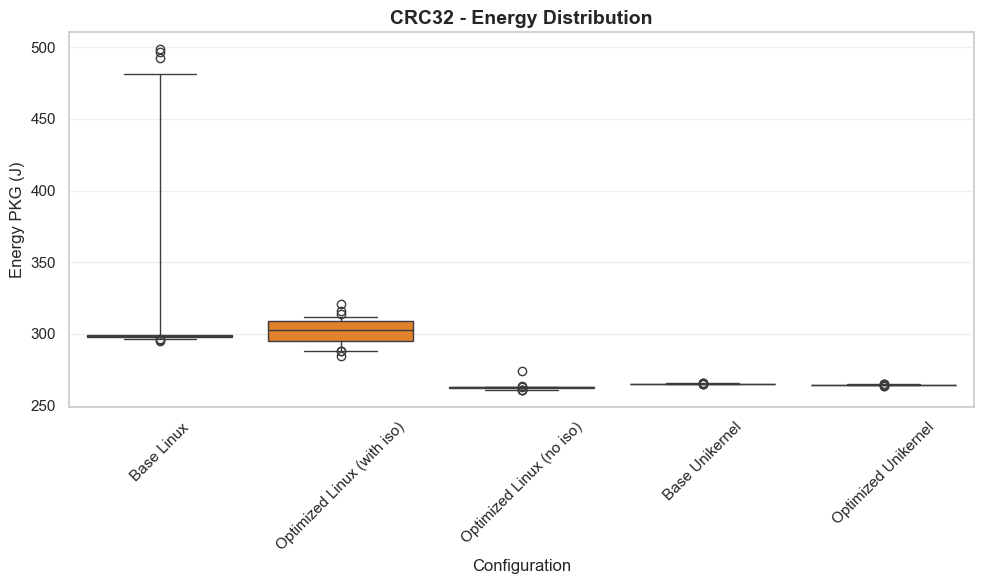

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/148487872.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


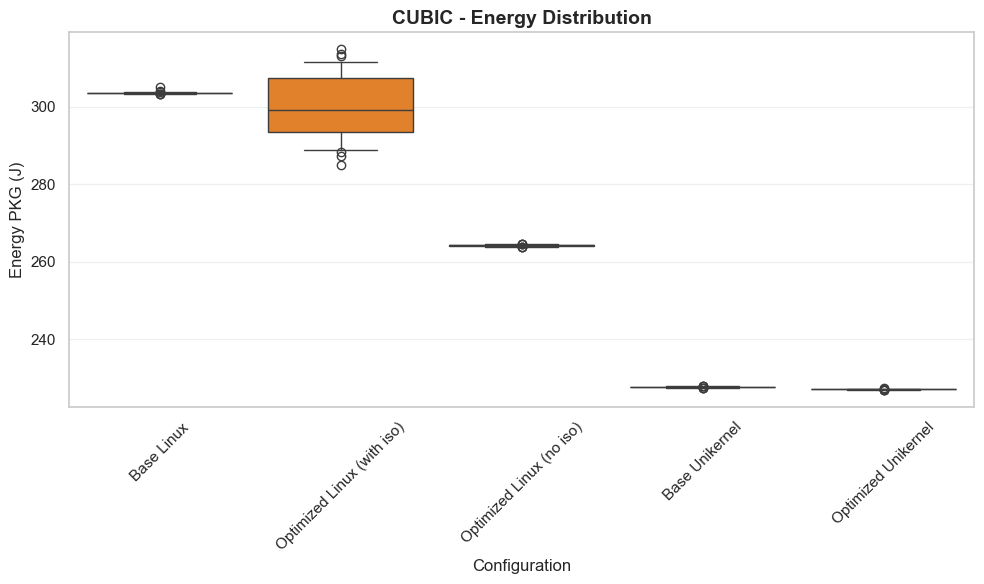

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/148487872.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


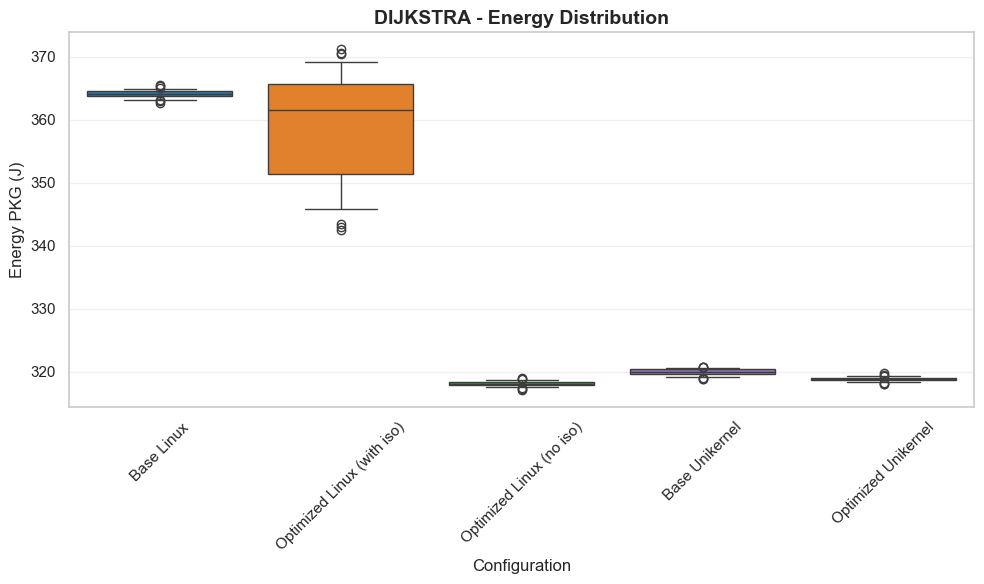

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/148487872.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


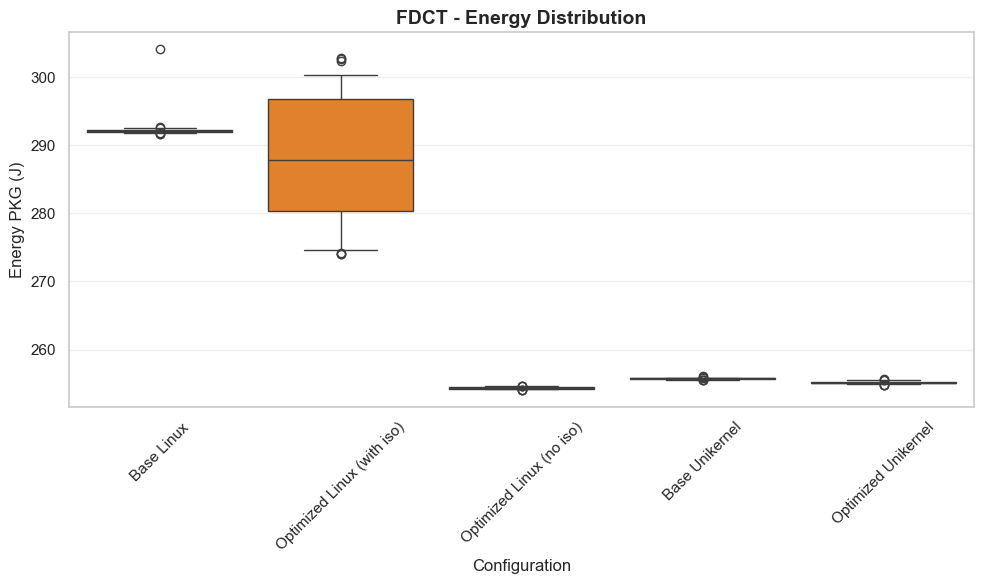

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/148487872.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


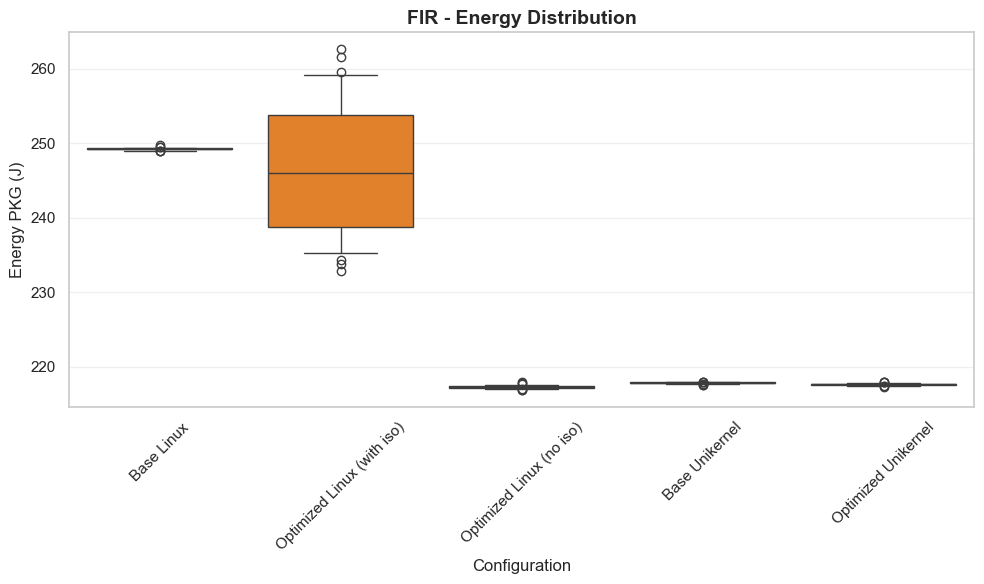

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/148487872.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


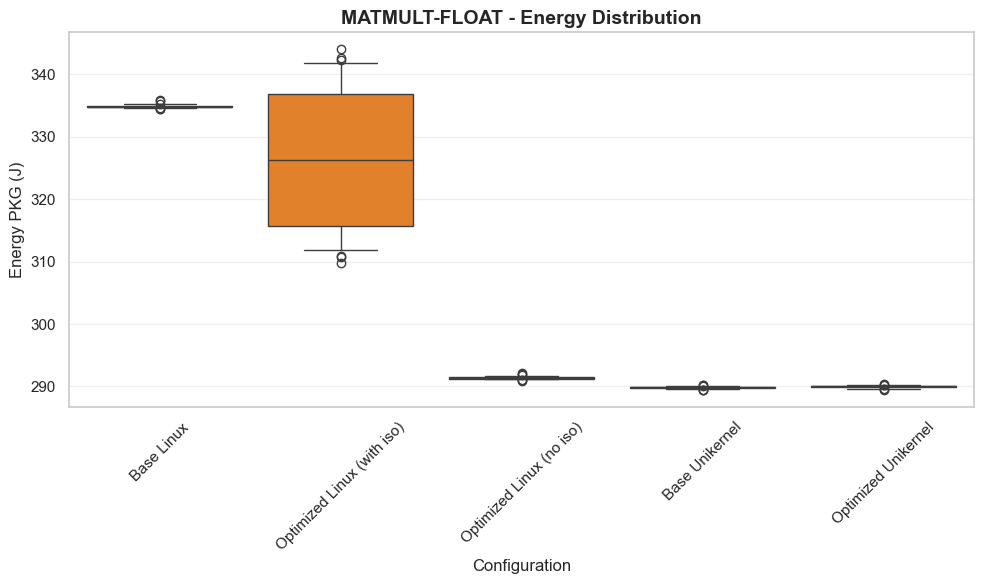

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/148487872.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


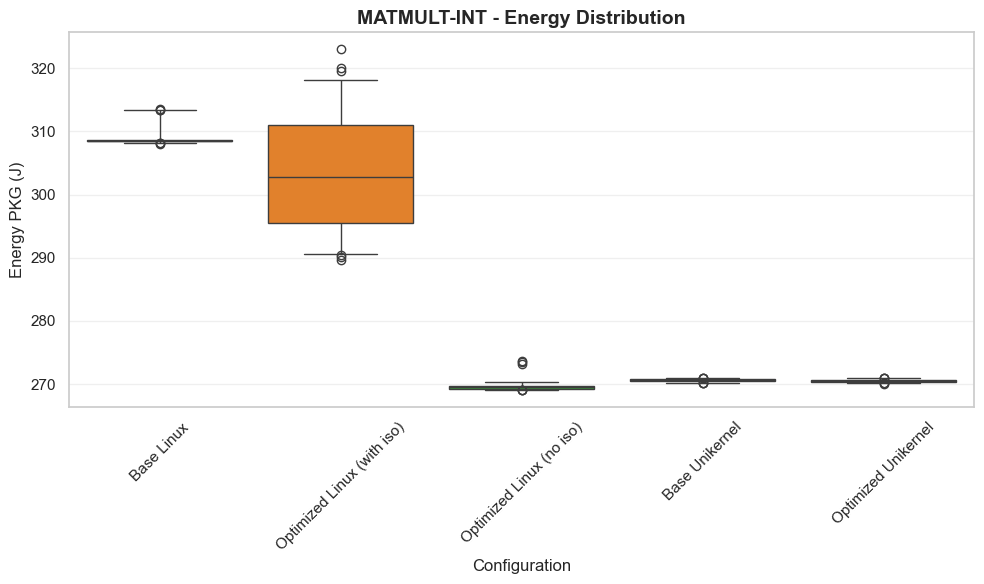

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/148487872.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


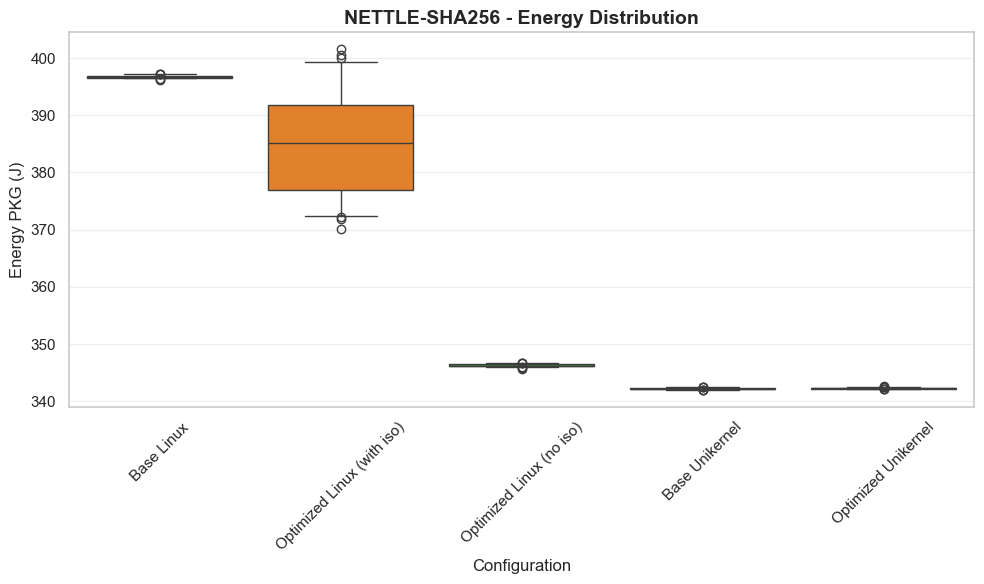

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/148487872.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


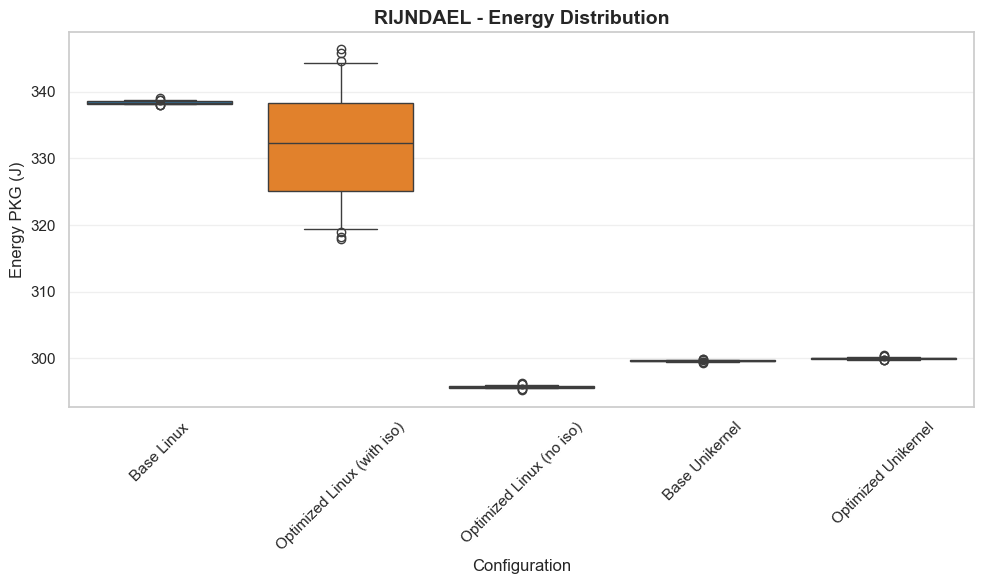

In [7]:
# Boxplot: Energy Consumption Distribution by Benchmark and Configuration
import matplotlib.pyplot as plt
import numpy as np

# Create individual boxplot for each benchmark
for benchmark in all_benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    benchmark_data = all_data[(all_data['benchmark'] == benchmark) & 
                               (all_data['source'].isin(hue_order))]
    
    sns.boxplot(
        data=benchmark_data,
        x='source',
        y='pkg_joules',
        hue='source',
        hue_order=hue_order,
        palette=palette[:len(hue_order)],
        ax=ax,
        order=hue_order,
        whis=(5, 95)
    )
    
    ax.set_xlabel('Configuration', fontsize=12)
    ax.set_ylabel('Energy PKG (J)', fontsize=12)
    ax.set_title(f'{str(benchmark).upper()} - Energy Distribution', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.legend().remove()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'energy_boxplot_{benchmark}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [8]:
# Summary statistics table
print("Summary Statistics: Energy Consumption (mJ)")
print("=" * 120)
print("\nMean Energy:")
display(mean_df)
print("\nCoefficient of Variation (%):")
display(cv_df)

Summary Statistics: Energy Consumption (mJ)

Mean Energy:


,Base Linux,Optimized Linux (with iso),Optimized Linux (no iso),Base Unikernel,Optimized Unikernel
Benchmark,,,,,
crc32,328745.85,301726.69,262707.42,467395.41,465826.24
cubic,303501.44,299847.51,264220.30,404317.49,403363.11
dijkstra,364126.38,358752.19,318074.14,574580.53,572378.22
fdct,292324.11,287968.92,254400.21,458899.90,457713.70
fir,249244.44,246435.44,217259.77,390180.30,389682.77
matmult-float,334835.89,326558.04,291355.68,523421.70,523581.87
matmult-int,309250.21,303687.46,269729.14,487140.26,486982.52
nettle-sha256,396754.68,385160.42,346256.11,622516.30,622324.43
rijndael,338380.31,332088.41,295722.56,541860.03,542193.38



Coefficient of Variation (%):


,Base Linux,Optimized Linux (with iso),Optimized Linux (no iso),Base Unikernel,Optimized Unikernel
Benchmark,,,,,
crc32,20.15,2.93,0.69,0.07,0.09
cubic,0.09,2.72,0.08,0.06,0.04
dijkstra,0.17,2.34,0.12,0.16,0.10
fdct,0.58,3.10,0.07,0.05,0.07
fir,0.06,3.46,0.09,0.05,0.07
matmult-float,0.08,3.26,0.08,0.06,0.07
matmult-int,0.58,3.20,0.37,0.09,0.09
nettle-sha256,0.07,2.33,0.07,0.04,0.04
rijndael,0.07,2.42,0.07,0.04,0.05


# Runtime Analysis

In [9]:
# Calculate mean and CV for runtime (time_ms)
runtime_data = []
for benchmark in all_benchmarks:
    benchmark_data = all_data[all_data['benchmark'] == benchmark]
    row = {'Benchmark': benchmark}
    for source in hue_order:
        source_data = benchmark_data[benchmark_data['source'] == source]['cpu_cycles']
        if len(source_data) > 0:
            mean = source_data.mean()
            row[f'{source} Mean (ms)'] = mean
            std = source_data.std()
            cv = (std / mean * 100) if mean != 0 else np.nan
            row[f'{source} CV (%)'] = cv
        else:
            row[f'{source} Mean (ms)'] = np.nan
            row[f'{source} CV (%)'] = np.nan
    runtime_data.append(row)

# Create DataFrame and display
runtime_df = pd.DataFrame(runtime_data)
runtime_df = runtime_df.set_index('Benchmark')

print("Runtime Statistics by Benchmark and Configuration")
print("=" * 120)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
display(runtime_df)

Runtime Statistics by Benchmark and Configuration


,Base Linux Mean (ms),Base Linux CV (%),Optimized Linux (with iso) Mean (ms),Optimized Linux (with iso) CV (%),Optimized Linux (no iso) Mean (ms),Optimized Linux (no iso) CV (%),Base Unikernel Mean (ms),Base Unikernel CV (%),Optimized Unikernel Mean (ms),Optimized Unikernel CV (%)
Benchmark,,,,,,,,,,
crc32,52596920727.0400,1.3744,75683626653.1800,8.1615,57275261019.2000,0.0195,57142010010.9600,0.0004,57139800930.6400,0.0002
cubic,48381765109.7600,0.0305,69748432612.4600,8.2328,52889538929.2000,0.0004,46061777958.1600,0.0007,46060098048.1600,0.0006
dijkstra,53282617439.2600,0.0990,77106777722.8000,7.8193,58476866391.1200,0.1021,58237857942.0000,0.2144,58123226034.0800,0.0778
fdct,43510294628.0400,0.0622,62656912624.1200,9.8501,47579685491.6000,0.0013,47363640941.2800,0.0112,47363572081.6800,0.0150
fir,37761551874.0000,0.0393,54813286324.1800,10.9328,41281050455.0400,0.0084,40998343816.9600,0.0054,41004252421.2000,0.0070
matmult-float,46281463903.7200,0.1666,66547023006.8200,11.1852,50523692789.8400,0.2008,50609352787.6000,0.0264,50609922557.4400,0.0656
matmult-int,44522670587.1200,0.5984,64604101155.5800,10.4573,48836635669.0400,0.3848,48627639262.0000,0.1031,48643017236.0000,0.0942
nettle-sha256,50503665827.6200,0.0241,72716087905.5400,8.4965,55338375618.4800,0.0022,55576393157.2000,0.0148,55575373047.1200,0.0133
rijndael,47239617795.1200,0.0430,68286014142.5000,8.2831,51778923508.1600,0.0009,51682192103.9200,0.0006,51680178067.2800,0.0006


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/1152478467.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


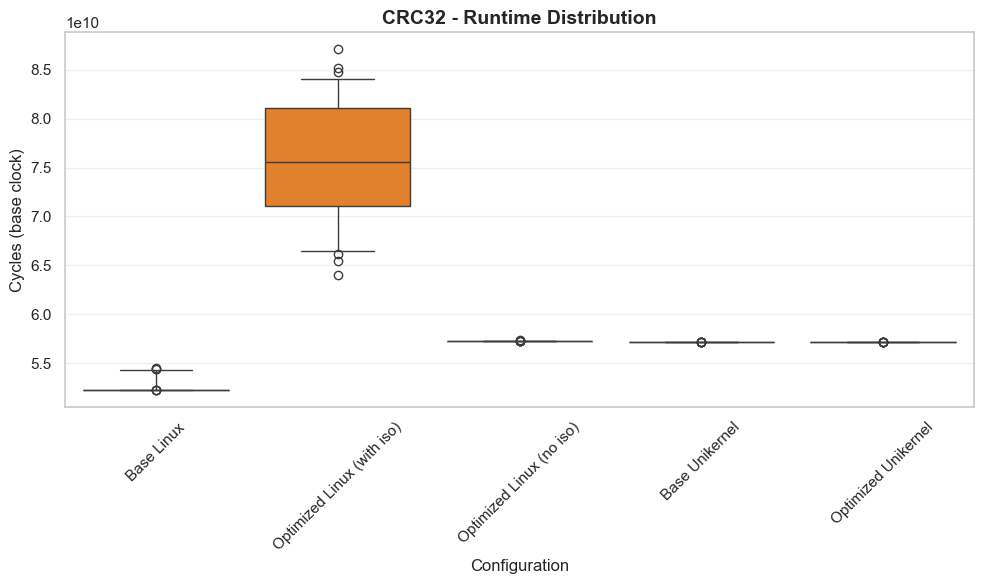

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/1152478467.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


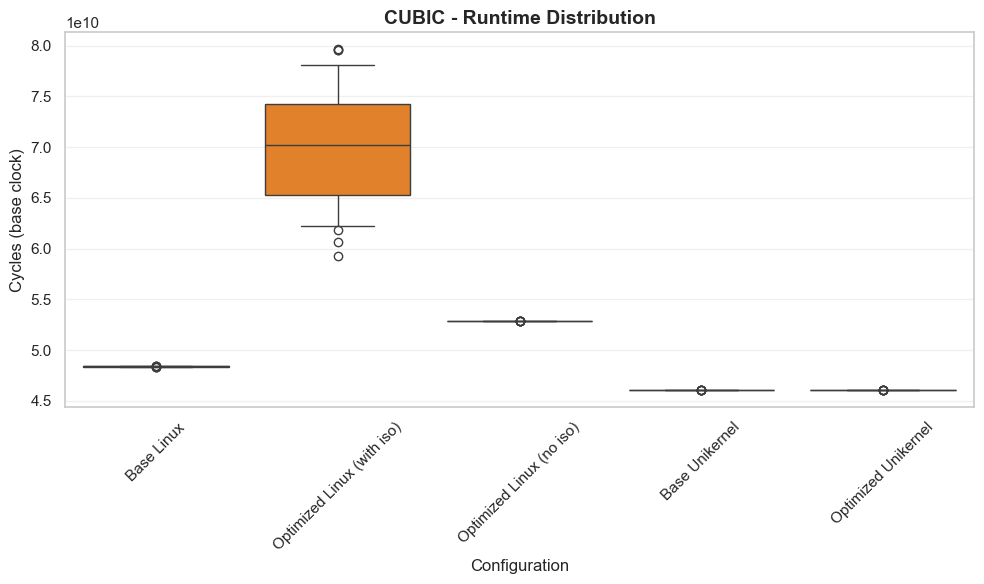

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/1152478467.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


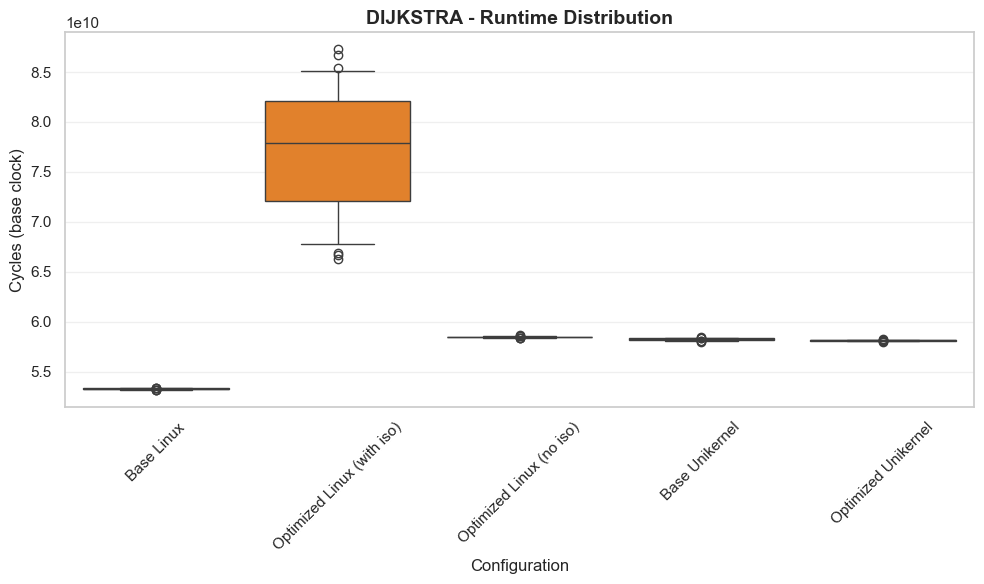

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/1152478467.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


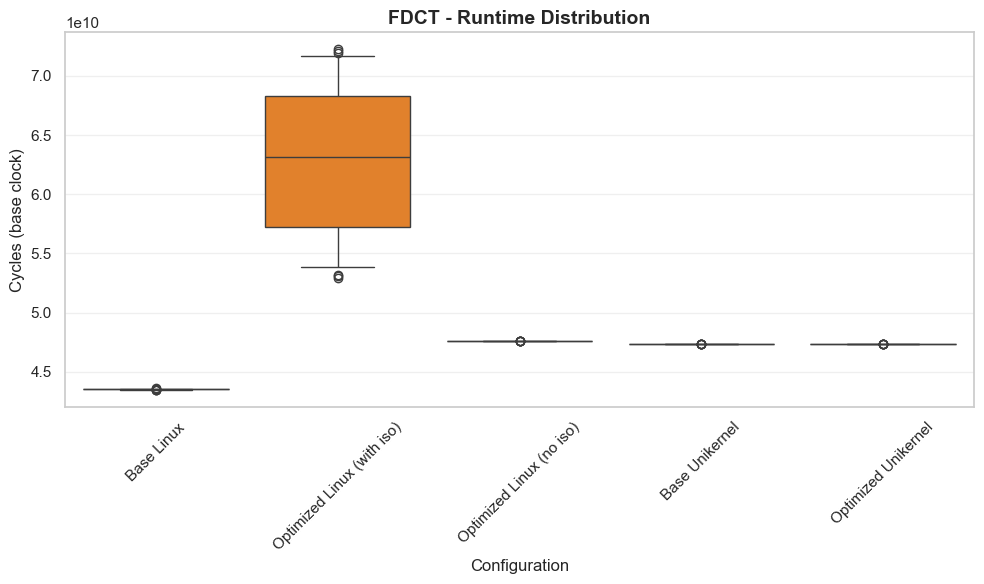

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/1152478467.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


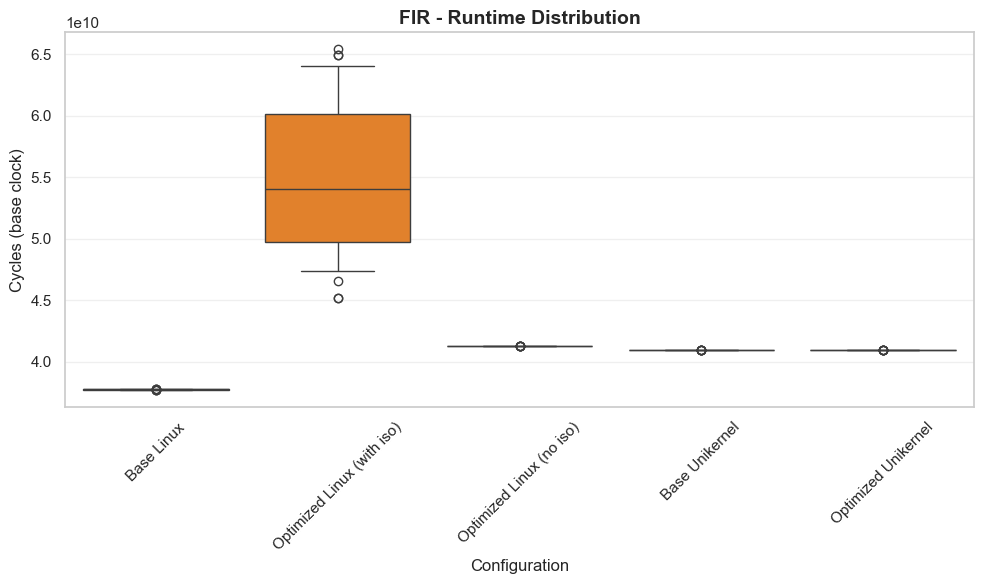

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/1152478467.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


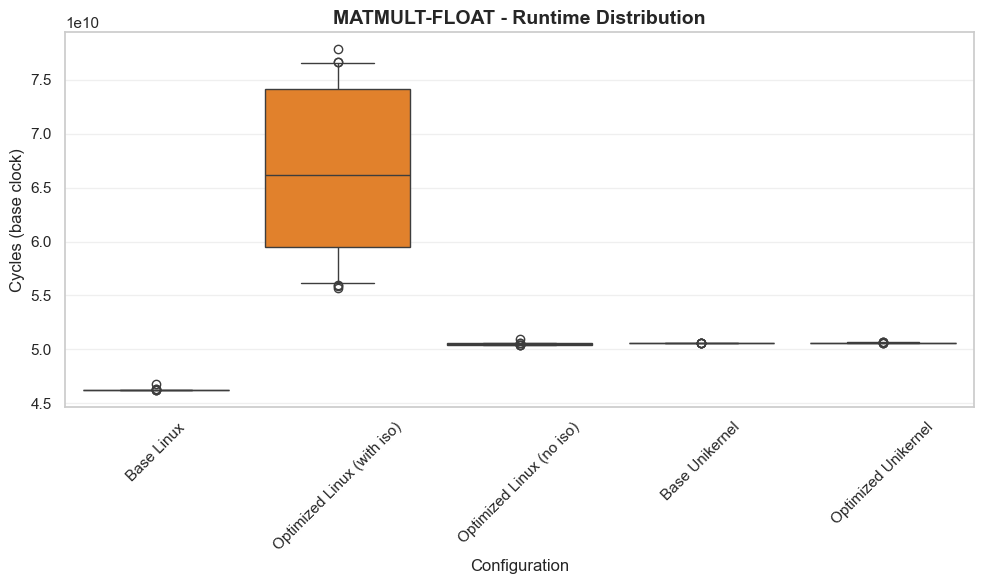

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/1152478467.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


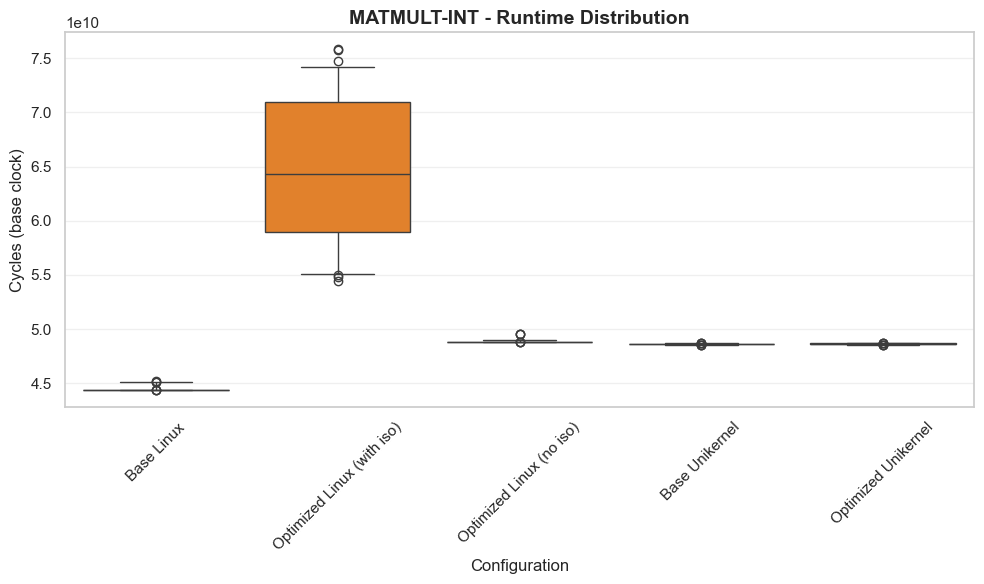

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/1152478467.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


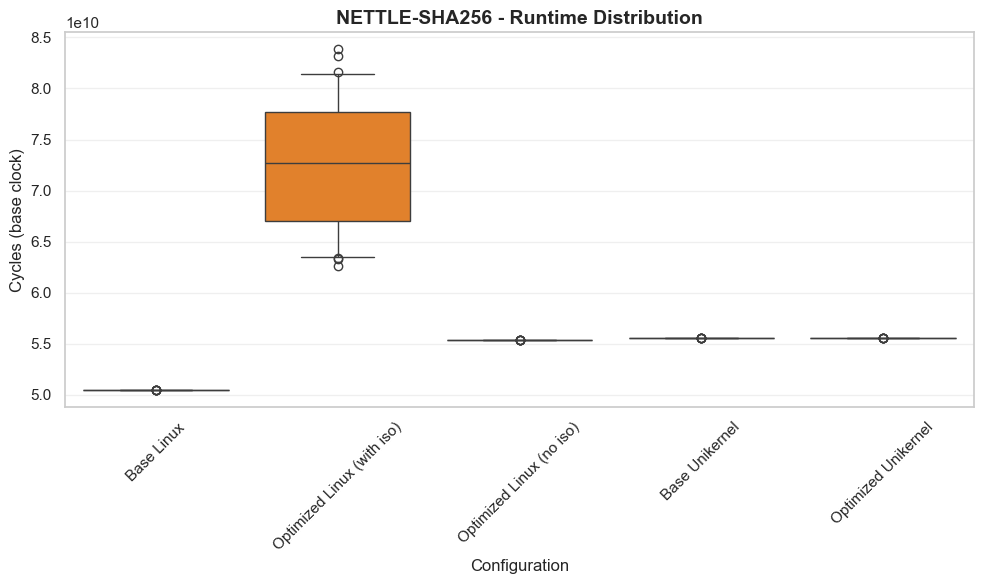

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/1152478467.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


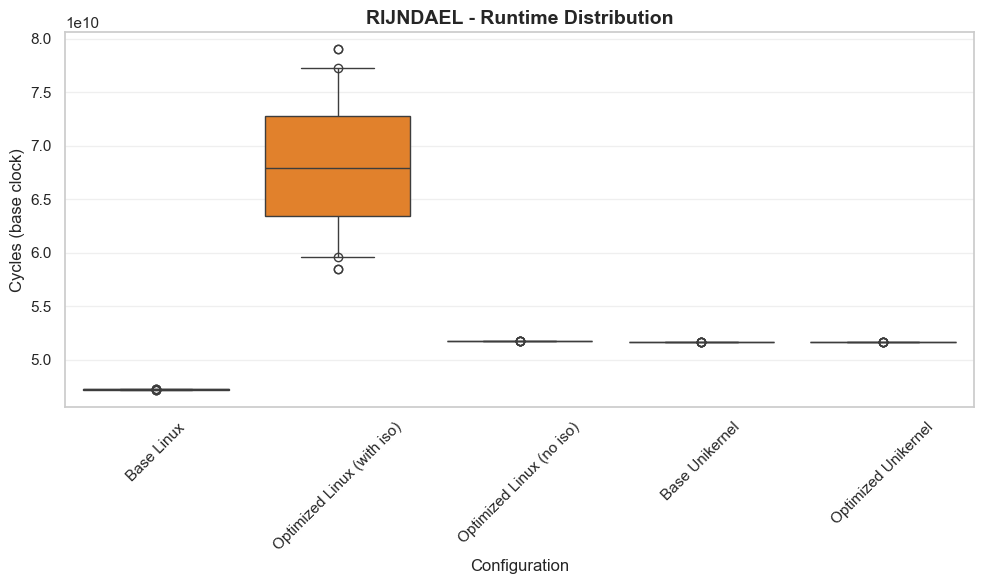

In [10]:
# Boxplot: Runtime Distribution by Benchmark and Configuration
import matplotlib.pyplot as plt
import numpy as np

# Create individual boxplot for each benchmark
for benchmark in all_benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    benchmark_data = all_data[(all_data['benchmark'] == benchmark) & 
                               (all_data['source'].isin(hue_order))]
    
    sns.boxplot(
        data=benchmark_data,
        x='source',
        y='cpu_cycles',
        hue='source',
        hue_order=hue_order,
        palette=palette[:len(hue_order)],
        ax=ax,
        order=hue_order,
        whis=(5, 95)
    )
    
    ax.set_xlabel('Configuration', fontsize=12)
    ax.set_ylabel('Cycles (base clock)', fontsize=12)
    ax.set_title(f'{str(benchmark).upper()} - Runtime Distribution', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.legend().remove()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'runtime_boxplot_{benchmark}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [11]:
# Compare mean runtime across configurations
runtime_mean = all_data.groupby(['benchmark', 'source'])['time_ms'].mean().unstack()
runtime_mean = runtime_mean[hue_order]

print("Mean Runtime (ms) by Benchmark and Configuration")
print("=" * 120)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
display(runtime_mean)

# Calculate percentage difference compared to first configuration
if len(hue_order) > 1:
    base_config = hue_order[0]
    runtime_diff = pd.DataFrame(index=runtime_mean.index)
    
    for source in hue_order[1:]:
        if source in runtime_mean.columns:
            runtime_diff[source] = ((runtime_mean[source] - runtime_mean[base_config]) / runtime_mean[base_config]) * 100
    
    print(f"\nPercentage difference in runtime compared to {base_config} (%)")
    print("=" * 120)
    display(runtime_diff)

Mean Runtime (ms) by Benchmark and Configuration


source,Base Linux,Optimized Linux (with iso),Optimized Linux (no iso),Base Unikernel,Optimized Unikernel
benchmark,,,,,
crc32,17005.42,24517.50,18518.19,18475.38,18474.68
cubic,15642.93,22553.84,17100.47,14892.88,14892.35
dijkstra,17227.50,24957.86,18906.90,18829.70,18792.65
fdct,14067.99,20290.73,15383.75,15313.80,15313.79
fir,12209.32,17729.30,13347.31,13255.75,13257.67
matmult-float,14963.96,21545.97,16335.59,16363.22,16363.41
matmult-int,14395.28,20905.57,15790.13,15722.48,15727.47
nettle-sha256,16329.04,23533.20,17892.19,17969.18,17968.86
rijndael,15273.70,22094.08,16741.39,16710.09,16709.45



Percentage difference in runtime compared to Base Linux (%)


,Optimized Linux (with iso),Optimized Linux (no iso),Base Unikernel,Optimized Unikernel
benchmark,,,,
crc32,44.17,8.90,8.64,8.64
cubic,44.18,9.32,-4.79,-4.80
dijkstra,44.87,9.75,9.30,9.09
fdct,44.23,9.35,8.86,8.86
fir,45.21,9.32,8.57,8.59
matmult-float,43.99,9.17,9.35,9.35
matmult-int,45.23,9.69,9.22,9.25
nettle-sha256,44.12,9.57,10.04,10.04
rijndael,44.65,9.61,9.40,9.40


# Power Measurements Analysis (binary_output files)

In [12]:
# Load all binary_output files (power measurements during benchmarks)
import glob
from pathlib import Path

power_data_list = []

for name, path in datasets.items():
    folder = path.parent
    # Find all binary_output files in this folder
    binary_files = sorted(glob.glob(str(folder / "binary_output_*.log")))
    
    print(f"\n{name}: Found {len(binary_files)} power measurement files")
    
    for file_path in binary_files:
        # Extract benchmark name and iteration from filename
        # e.g., binary_output_crc32_0.log -> benchmark=crc32, iteration=0
        filename = Path(file_path).stem
        parts = filename.replace('binary_output_', '').rsplit('_', 1)
        
        if len(parts) == 2:
            benchmark_name = parts[0]
            iteration = int(parts[1])
            
            # Read the CSV file
            try:
                df = pd.read_csv(file_path)
                df['benchmark'] = benchmark_name
                df['iteration'] = iteration
                df['source'] = name
                power_data_list.append(df)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

# Combine all power data
power_data = pd.concat(power_data_list, ignore_index=True)

print(f"\nTotal power measurements loaded: {len(power_data)} rows")
print(f"Unique benchmarks: {power_data['benchmark'].unique()}")
print(f"\nSample data:")
display(power_data.head())


Base Linux: Found 450 power measurement files

Base Unikernel: Found 450 power measurement files

Optimized Linux (with iso): Found 450 power measurement files

Optimized Linux (no iso): Found 450 power measurement files

Optimized Unikernel: Found 450 power measurement files

Total power measurements loaded: 905734 rows
Unique benchmarks: ['crc32' 'cubic' 'dijkstra' 'fdct' 'fir' 'matmult-float' 'matmult-int'
 'nettle-sha256' 'rijndael']

Sample data:


,unix_timestamp,active_power (mW),benchmark,iteration,source
0,1769679226797480,49380,crc32,0,Base Linux
1,1769679226840548,30650,crc32,0,Base Linux
2,1769679226883642,47620,crc32,0,Base Linux
3,1769679226926374,45280,crc32,0,Base Linux
4,1769679226969460,44590,crc32,0,Base Linux


In [13]:
# Calculate power statistics for each benchmark run
power_stats_list = []

for name in hue_order:
    source_data = power_data[power_data['source'] == name]
    
    for benchmark in all_benchmarks:
        benchmark_data = source_data[source_data['benchmark'] == benchmark]
        
        for iteration in benchmark_data['iteration'].unique():
            iter_data = benchmark_data[benchmark_data['iteration'] == iteration]
            
            if len(iter_data) > 0:
                stats = {
                    'source': name,
                    'benchmark': benchmark,
                    'iteration': iteration,
                    'mean_power_mW': iter_data['active_power (mW)'].mean(),
                    'std_power_mW': iter_data['active_power (mW)'].std(),
                    'min_power_mW': iter_data['active_power (mW)'].min(),
                    'max_power_mW': iter_data['active_power (mW)'].max(),
                    'median_power_mW': iter_data['active_power (mW)'].median(),
                    'samples': len(iter_data)
                }
                power_stats_list.append(stats)

power_stats = pd.DataFrame(power_stats_list)

print("Power Statistics Summary:")
print("=" * 120)
print(f"Total runs analyzed: {len(power_stats)}")
display(power_stats.head(20))

Power Statistics Summary:
Total runs analyzed: 2250


,source,benchmark,iteration,mean_power_mW,std_power_mW,min_power_mW,max_power_mW,median_power_mW,samples
0,Base Linux,crc32,0,44595.62,764.83,30650,49380,44600.00,393
1,Base Linux,crc32,1,44664.07,93.47,44470,45330,44660.00,391
2,Base Linux,crc32,10,44857.14,83.09,44580,45240,44860.00,391
3,Base Linux,crc32,11,44903.94,179.28,44690,47960,44900.00,391
4,Base Linux,crc32,12,44802.02,75.66,44650,45070,44790.00,391
5,Base Linux,crc32,13,44891.41,140.12,44560,46360,44890.00,391
6,Base Linux,crc32,14,44923.02,161.82,44670,47750,44920.00,391
7,Base Linux,crc32,15,44918.06,85.56,44710,45520,44930.00,391
8,Base Linux,crc32,16,44858.08,445.67,37210,48110,44870.00,391
9,Base Linux,crc32,17,44857.75,89.15,44620,45080,44850.00,391


In [14]:
# Compare mean power consumption across configurations
mean_power_by_config = power_stats.groupby(['benchmark', 'source'])['mean_power_mW'].agg(['mean', 'std']).reset_index()
mean_power_pivot = mean_power_by_config.pivot(index='benchmark', columns='source', values='mean')
mean_power_pivot = mean_power_pivot[hue_order]

print("Mean Power Consumption (mW) by Benchmark and Configuration")
print("=" * 120)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
display(mean_power_pivot)

# Calculate coefficient of variation for power
cv_power_data = []
for benchmark in all_benchmarks:
    row = {'Benchmark': benchmark}
    for source in hue_order:
        source_data = power_stats[(power_stats['benchmark'] == benchmark) & 
                                   (power_stats['source'] == source)]['mean_power_mW']
        if len(source_data) > 0:
            mean = source_data.mean()
            std = source_data.std()
            cv = (std / mean * 100) if mean != 0 else np.nan
            row[source] = cv
        else:
            row[source] = np.nan
    cv_power_data.append(row)

cv_power_df = pd.DataFrame(cv_power_data).set_index('Benchmark')

print("\nCoefficient of Variation for Power Consumption (%)")
print("=" * 120)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
display(cv_power_df)

Mean Power Consumption (mW) by Benchmark and Configuration


source,Base Linux,Optimized Linux (with iso),Optimized Linux (no iso),Base Unikernel,Optimized Unikernel
benchmark,,,,,
crc32,46808.96,36174.83,40399.90,42436.95,42915.14
cubic,47429.63,37536.57,42160.31,43799.00,44308.36
dijkstra,49818.42,38900.99,44034.87,45970.69,46527.11
fdct,48271.55,38114.39,42852.81,44856.48,45417.96
fir,48056.40,37922.02,42752.92,44749.41,45283.75
matmult-float,49370.72,38730.59,43702.58,45348.28,45904.88
matmult-int,49141.87,38460.88,43482.22,45369.61,45941.72
nettle-sha256,49890.42,38960.88,44036.40,45787.63,46363.50
rijndael,48809.58,38327.37,43248.65,45272.20,45850.27



Coefficient of Variation for Power Consumption (%)


,Base Linux,Optimized Linux (with iso),Optimized Linux (no iso),Base Unikernel,Optimized Unikernel
Benchmark,,,,,
crc32,9.0368,3.1237,0.3092,0.0469,0.0379
cubic,0.1286,3.3937,0.0495,0.0627,0.0669
dijkstra,0.0646,3.5252,0.0480,0.0702,0.0975
fdct,0.3076,4.0956,0.0474,0.0760,0.0945
fir,0.1434,4.5113,0.0494,0.0717,0.0977
matmult-float,0.1134,4.8092,0.1720,0.0746,0.1100
matmult-int,0.2428,4.4774,0.2324,0.0706,0.1140
nettle-sha256,0.0760,3.6244,0.0597,0.0721,0.1154
rijndael,0.0943,3.5890,0.0519,0.0628,0.1127


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/477416027.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


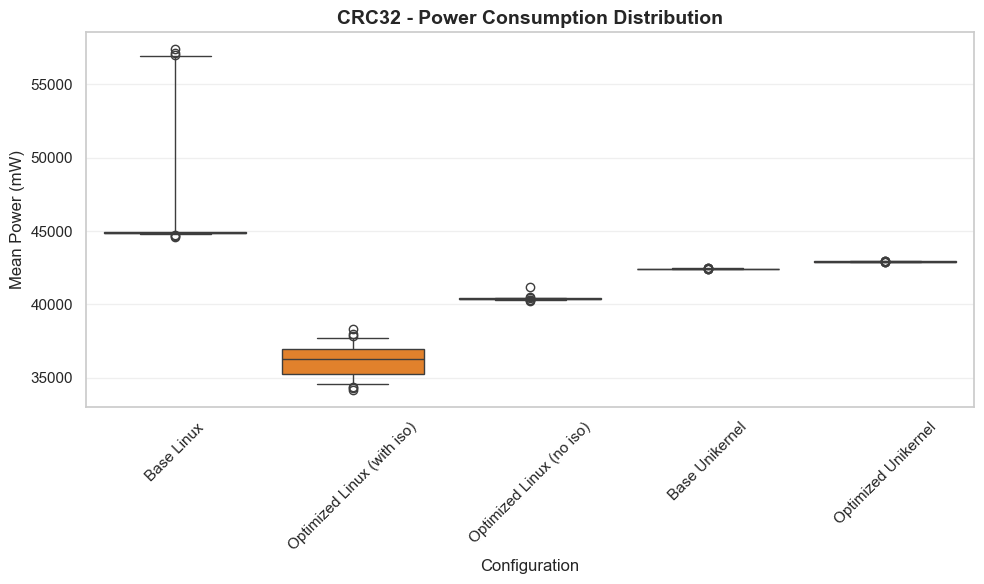

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/477416027.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


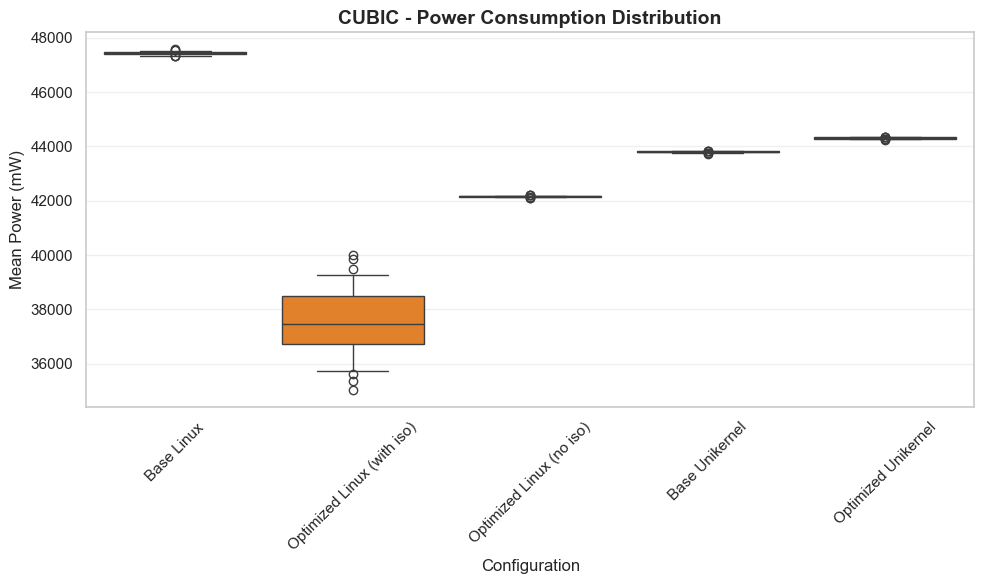

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/477416027.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


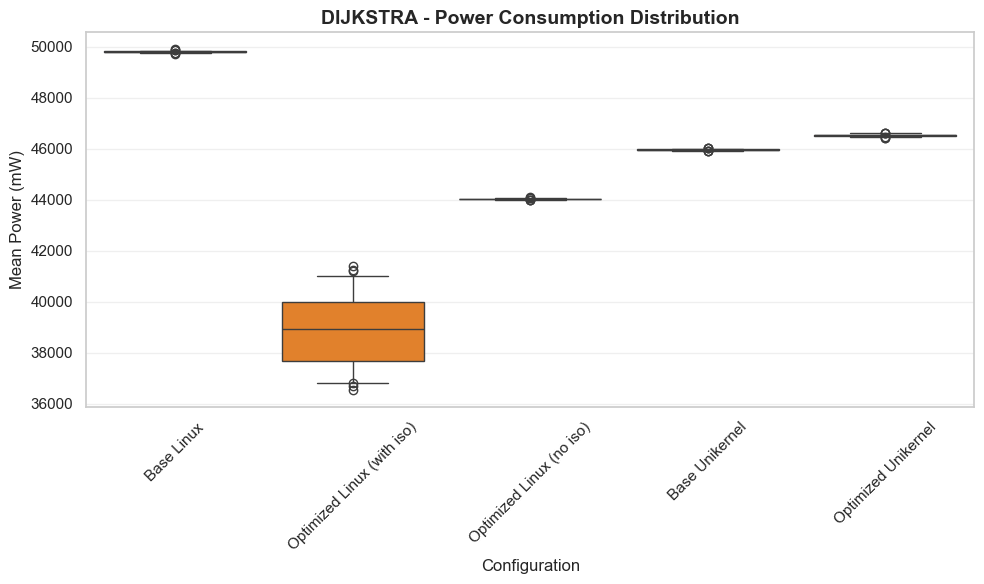

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/477416027.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


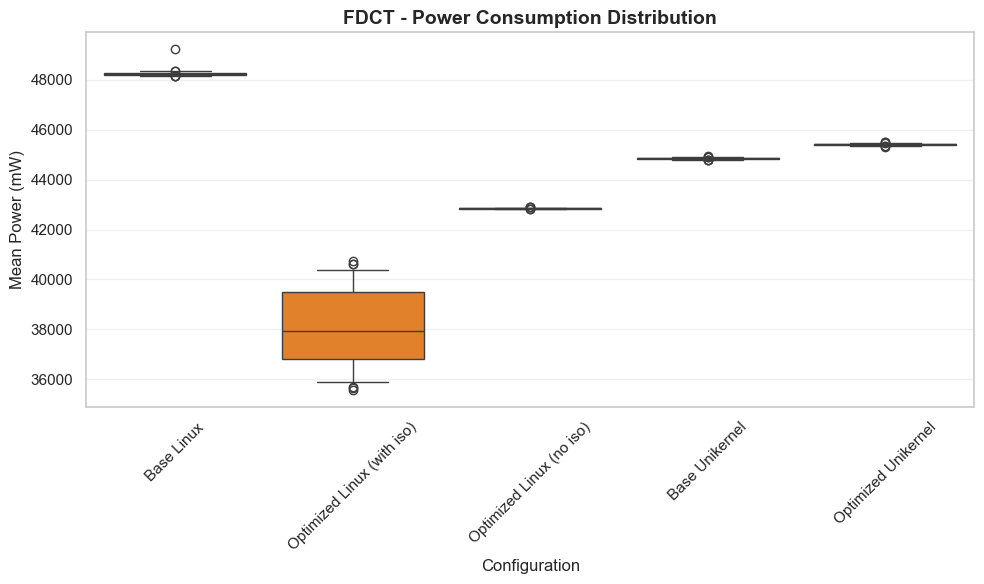

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/477416027.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


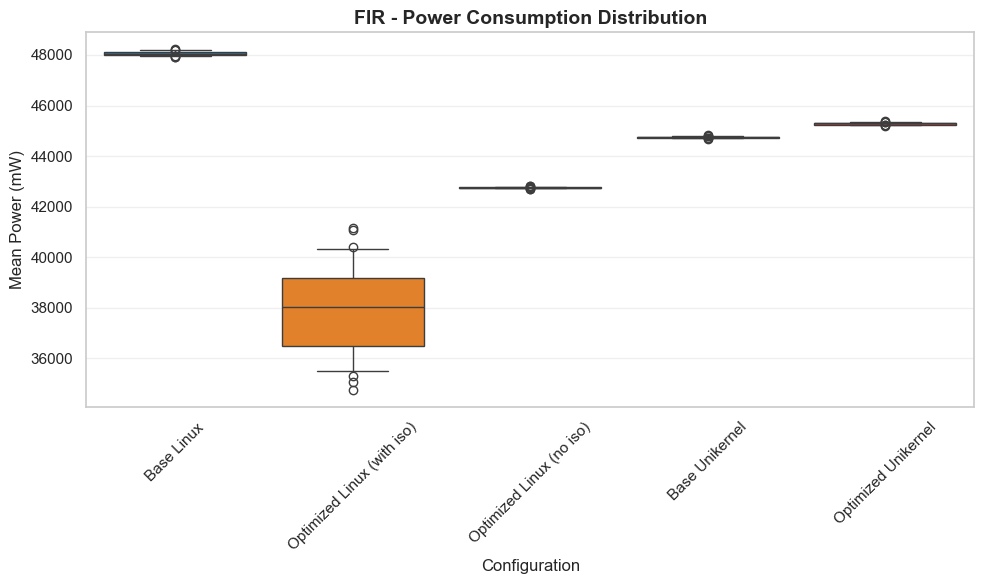

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/477416027.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


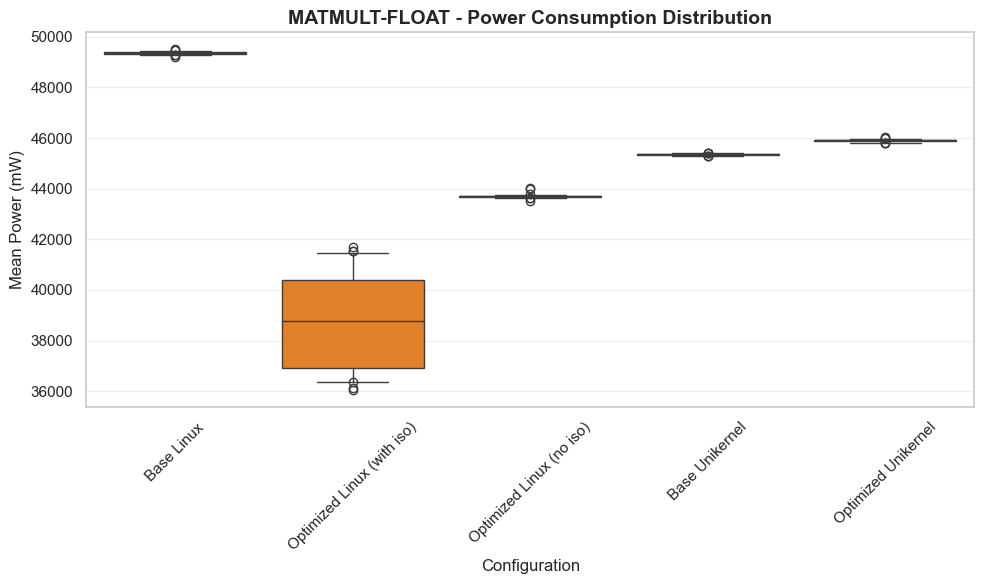

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/477416027.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


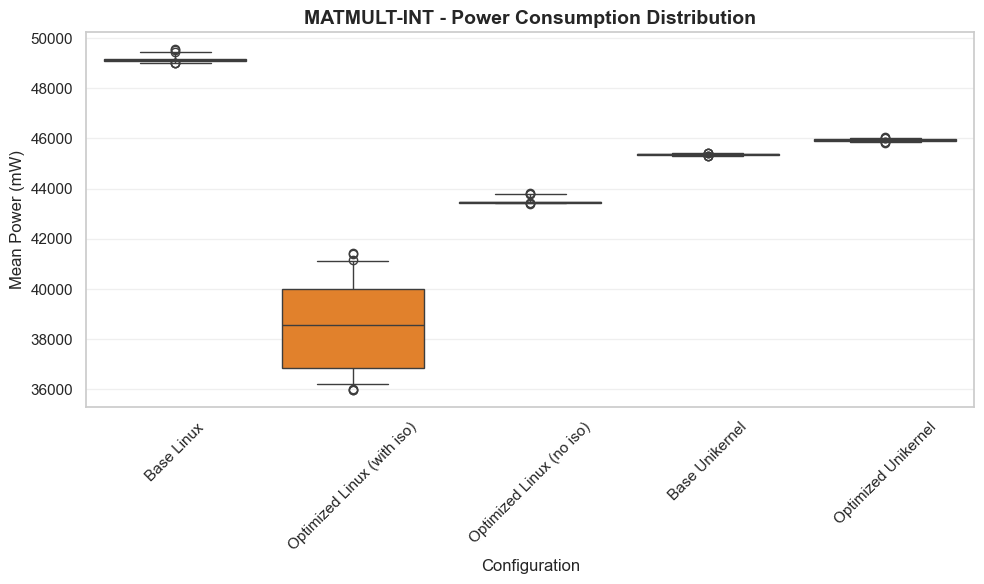

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/477416027.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


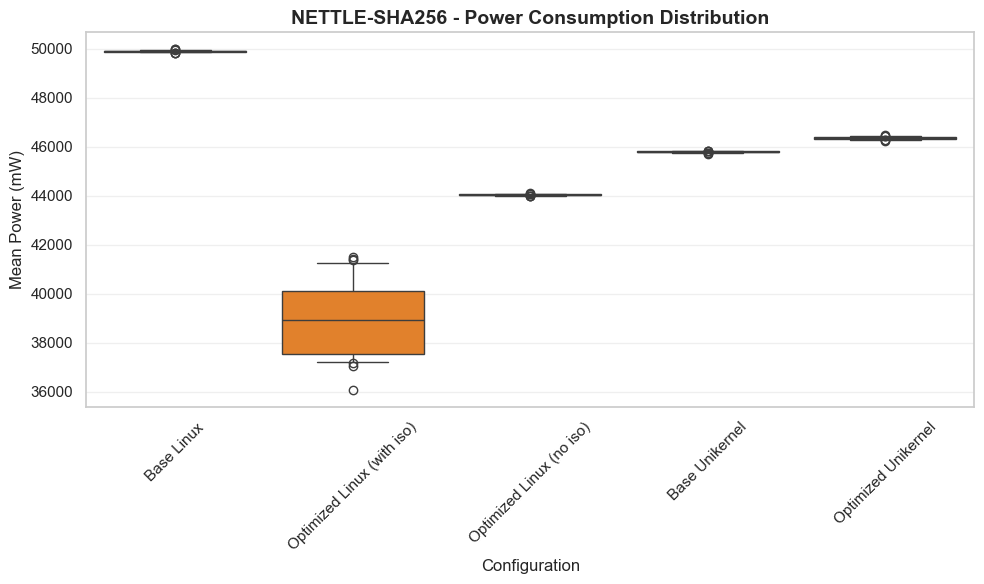

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_74327/477416027.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


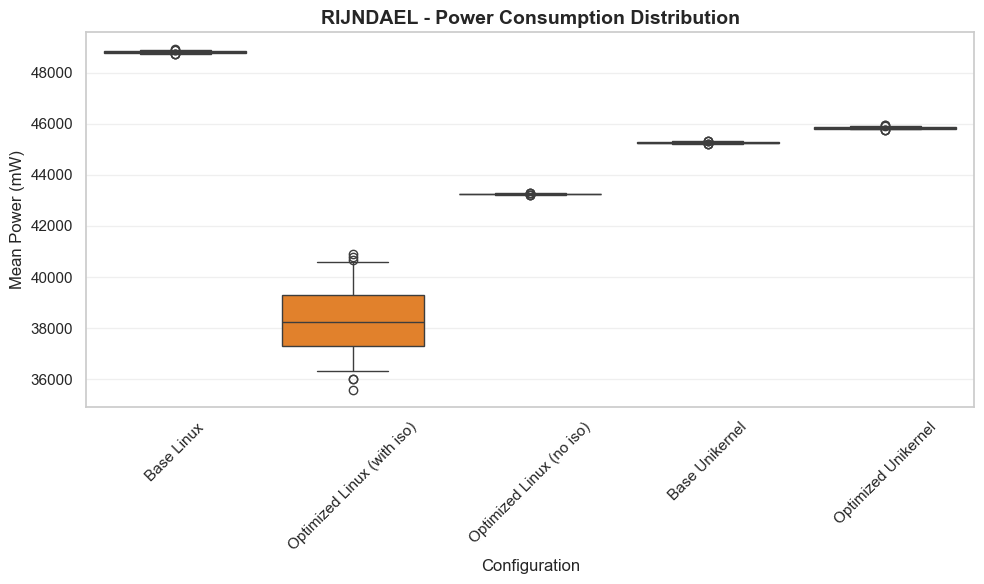

In [15]:
# Boxplot: Power consumption distribution by benchmark and configuration
import matplotlib.pyplot as plt

for benchmark in all_benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    benchmark_power = power_stats[(power_stats['benchmark'] == benchmark) & 
                                   (power_stats['source'].isin(hue_order))]
    
    sns.boxplot(
        data=benchmark_power,
        x='source',
        y='mean_power_mW',
        hue='source',
        hue_order=hue_order,
        palette=palette[:len(hue_order)],
        ax=ax,
        order=hue_order,
        whis=(5, 95)
    )
    
    ax.set_xlabel('Configuration', fontsize=12)
    ax.set_ylabel('Mean Power (mW)', fontsize=12)
    ax.set_title(f'{str(benchmark).upper()} - Power Consumption Distribution', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.legend().remove()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'power_boxplot_{benchmark}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [16]:
# Compare power percentage differences
if len(hue_order) > 1:
    base_config = hue_order[0]
    power_diff = pd.DataFrame(index=mean_power_pivot.index)
    
    for source in hue_order[1:]:
        if source in mean_power_pivot.columns:
            power_diff[source] = ((mean_power_pivot[source] - mean_power_pivot[base_config]) / mean_power_pivot[base_config]) * 100
    
    print(f"Percentage difference in mean power compared to {base_config} (%)")
    print("=" * 120)
    pd.set_option('display.float_format', lambda x: f'{x:.2f}')
    display(power_diff)

Percentage difference in mean power compared to Base Linux (%)


,Optimized Linux (with iso),Optimized Linux (no iso),Base Unikernel,Optimized Unikernel
benchmark,,,,
crc32,-22.72,-13.69,-9.34,-8.32
cubic,-20.86,-11.11,-7.65,-6.58
dijkstra,-21.91,-11.61,-7.72,-6.61
fdct,-21.04,-11.23,-7.07,-5.91
fir,-21.09,-11.04,-6.88,-5.77
matmult-float,-21.55,-11.48,-8.15,-7.02
matmult-int,-21.74,-11.52,-7.68,-6.51
nettle-sha256,-21.91,-11.73,-8.22,-7.07
rijndael,-21.48,-11.39,-7.25,-6.06


# Correlation: PKG Energy vs Power Meter Energy

In [17]:
# Calculate energy from power meter measurements
# Energy = Average Power * Time
# Merge power stats with original RAPL data to get runtime

merged_data = []

for idx, row in power_stats.iterrows():
    # Find matching RAPL measurement
    rapl_match = all_data[
        (all_data['benchmark'] == row['benchmark']) &
        (all_data['source'] == row['source'])
    ]
    
    if len(rapl_match) >= row['iteration']:
        rapl_row = rapl_match.iloc[row['iteration']]
        
        # Calculate energy from power meter: Power (mW) * Time (ms) / 1000 = Energy (mJ)
        # Then convert to Joules
        power_meter_energy_J = (row['mean_power_mW']/1000) * (rapl_row['time_ms']/1000)
        
        merged_data.append({
            'benchmark': row['benchmark'],
            'source': row['source'],
            'iteration': row['iteration'],
            'pkg_energy_J': rapl_row['pkg_joules'],
            'power_meter_energy_J': power_meter_energy_J,
            'mean_power_mW': row['mean_power_mW'],
            'time_ms': rapl_row['time_ms']
        })

energy_comparison = pd.DataFrame(merged_data)

print(f"Energy comparison dataset: {len(energy_comparison)} measurements")
print("\nSample data:")
display(energy_comparison.head(20))

Energy comparison dataset: 2250 measurements

Sample data:


,benchmark,source,iteration,pkg_energy_J,power_meter_energy_J,mean_power_mW,time_ms
0,crc32,Base Linux,0,295.30,753.58,44595.62,16898.00
1,crc32,Base Linux,1,295.67,754.68,44664.07,16896.72
2,crc32,Base Linux,10,297.46,757.95,44857.14,16896.87
3,crc32,Base Linux,11,297.83,758.77,44903.94,16897.66
4,crc32,Base Linux,12,297.92,757.05,44802.02,16897.66
5,crc32,Base Linux,13,297.82,758.57,44891.41,16897.81
6,crc32,Base Linux,14,298.02,759.11,44923.02,16898.11
7,crc32,Base Linux,15,298.05,758.97,44918.06,16896.77
8,crc32,Base Linux,16,298.17,758.03,44858.08,16898.38
9,crc32,Base Linux,17,298.10,757.95,44857.75,16896.71


In [18]:
# Calculate correlation statistics for each benchmark and configuration
from scipy import stats

print("Correlation Analysis: PKG Energy vs Power Meter Energy")
print("=" * 120)
print()

correlation_results = []

for benchmark in all_benchmarks:
    print(f"\n{str(benchmark).upper()}:")
    print("-" * 120)
    
    benchmark_data = energy_comparison[energy_comparison['benchmark'] == benchmark]
    
    for source in hue_order:
        source_data = benchmark_data[benchmark_data['source'] == source]
        
        if len(source_data) > 2:
            pkg = source_data['pkg_energy_J']
            power_meter = source_data['power_meter_energy_J']
            
            # Calculate Pearson correlation
            corr, p_value = stats.pearsonr(pkg, power_meter)
            
            # Calculate mean absolute error and relative error
            mae = np.abs(pkg - power_meter).mean()
            relative_error = ((power_meter - pkg) / pkg * 100).mean()
            
            correlation_results.append({
                'benchmark': benchmark,
                'source': source,
                'correlation': corr,
                'p_value': p_value,
                'mae_J': mae,
                'relative_error_%': relative_error,
                'n_samples': len(source_data)
            })
            
            print(f"  {source:30s} | r={corr:.4f} (p={p_value:.2e}) | MAE={mae:.4f}J | Rel.Error={relative_error:+.2f}% | n={len(source_data)}")

print("\n" + "=" * 120)

# Create summary DataFrame
correlation_df = pd.DataFrame(correlation_results)
print("\nCorrelation Summary:")
display(correlation_df)

Correlation Analysis: PKG Energy vs Power Meter Energy


CRC32:
------------------------------------------------------------------------------------------------------------------------
  Base Linux                     | r=0.9983 (p=8.40e-61) | MAE=468.2242J | Rel.Error=+145.93% | n=50
  Optimized Linux (with iso)     | r=0.9926 (p=1.32e-45) | MAE=583.1096J | Rel.Error=+193.08% | n=50
  Optimized Linux (no iso)       | r=0.9760 (p=2.06e-33) | MAE=485.4261J | Rel.Error=+184.79% | n=50
  Base Unikernel                 | r=0.2801 (p=4.89e-02) | MAE=518.8568J | Rel.Error=+195.66% | n=50
  Optimized Unikernel            | r=-0.4132 (p=2.86e-03) | MAE=528.5287J | Rel.Error=+199.96% | n=50

CUBIC:
------------------------------------------------------------------------------------------------------------------------
  Base Linux                     | r=0.5231 (p=9.73e-05) | MAE=438.4369J | Rel.Error=+144.46% | n=50
  Optimized Linux (with iso)     | r=0.9979 (p=7.44e-59) | MAE=544.4841J | Rel.

,benchmark,source,correlation,p_value,mae_J,relative_error_%,n_samples
0,crc32,Base Linux,1.00,0.00,468.22,145.93,50
1,crc32,Optimized Linux (with iso),0.99,0.00,583.11,193.08,50
2,crc32,Optimized Linux (no iso),0.98,0.00,485.43,184.79,50
3,crc32,Base Unikernel,0.28,0.05,518.86,195.66,50
4,crc32,Optimized Unikernel,-0.41,0.00,528.53,199.96,50
5,cubic,Base Linux,0.52,0.00,438.44,144.46,50
6,cubic,Optimized Linux (with iso),1.00,0.00,544.48,181.42,50
7,cubic,Optimized Linux (no iso),0.50,0.00,456.74,172.86,50
8,cubic,Base Unikernel,0.20,0.16,424.64,186.53,50
9,cubic,Optimized Unikernel,0.02,0.90,432.74,190.53,50


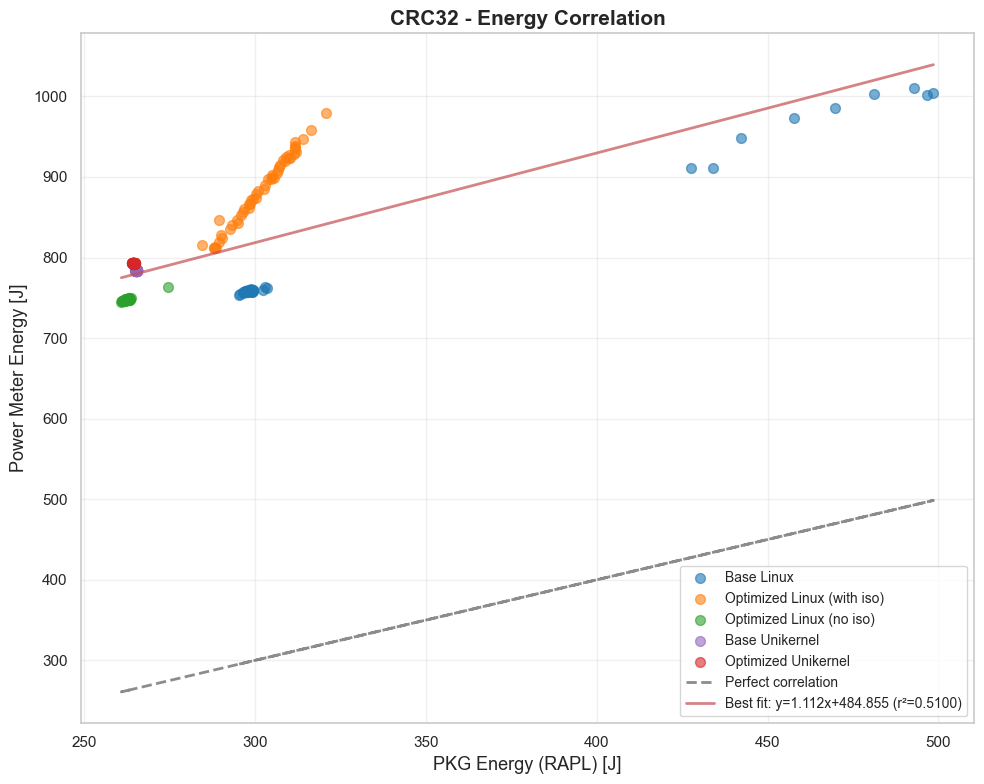

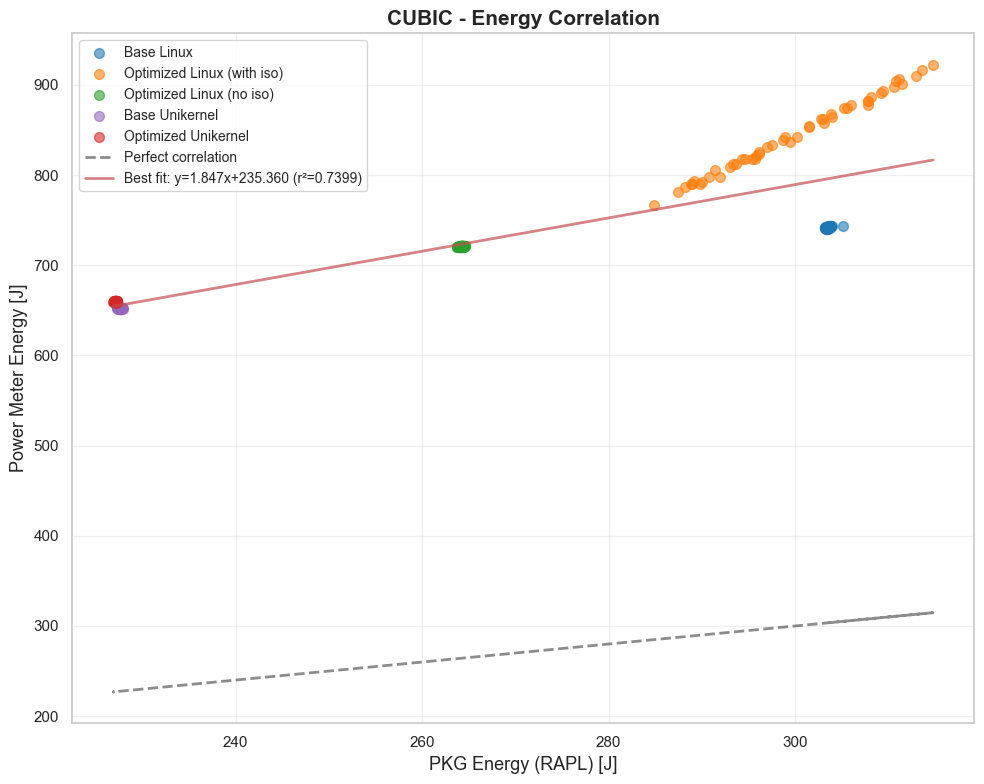

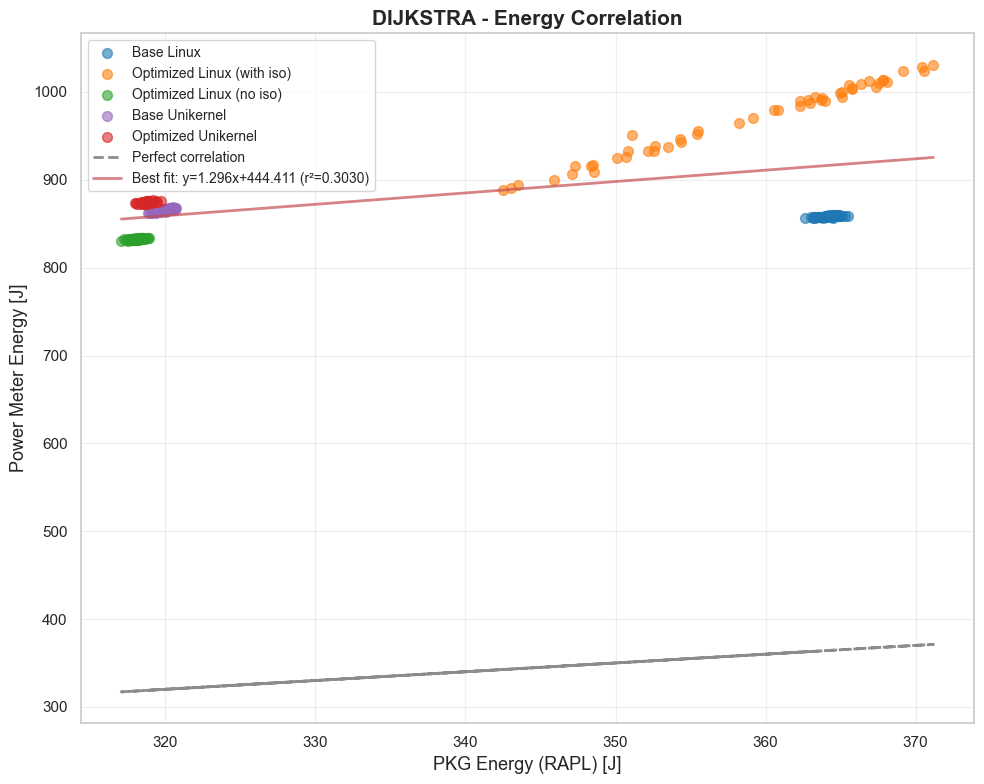

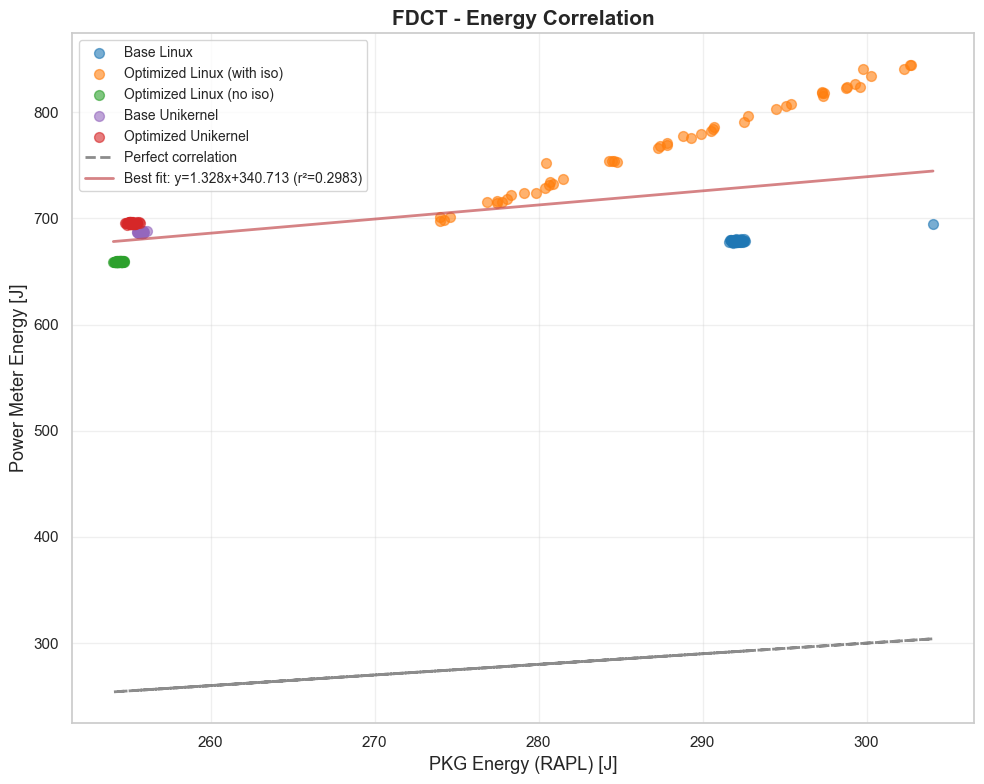

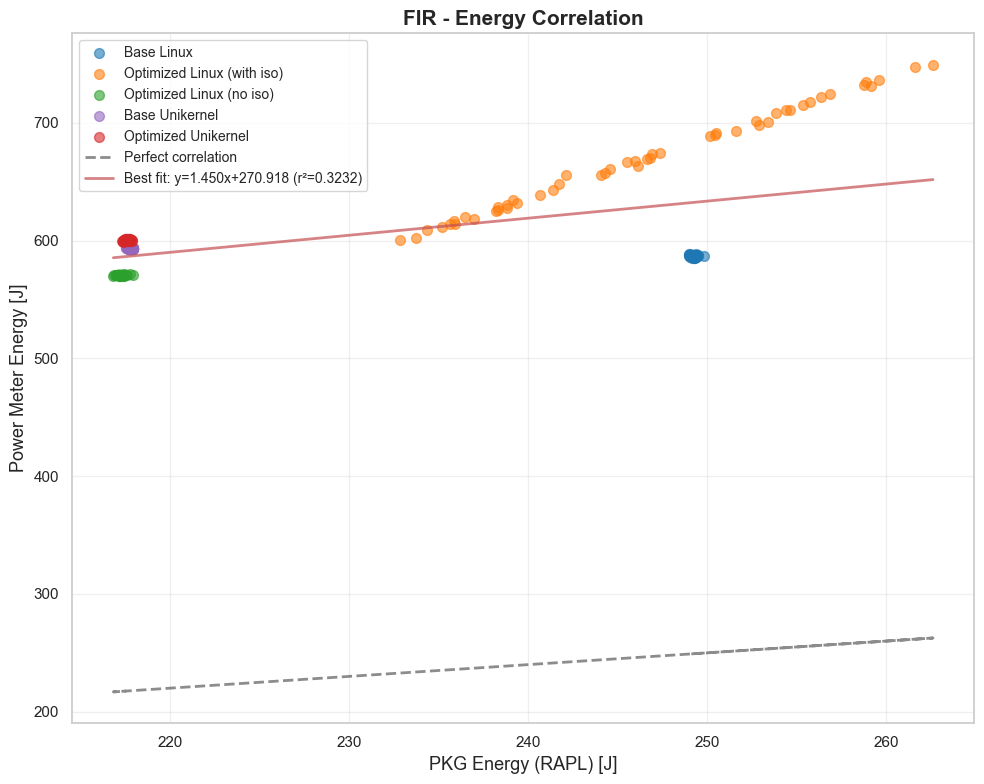

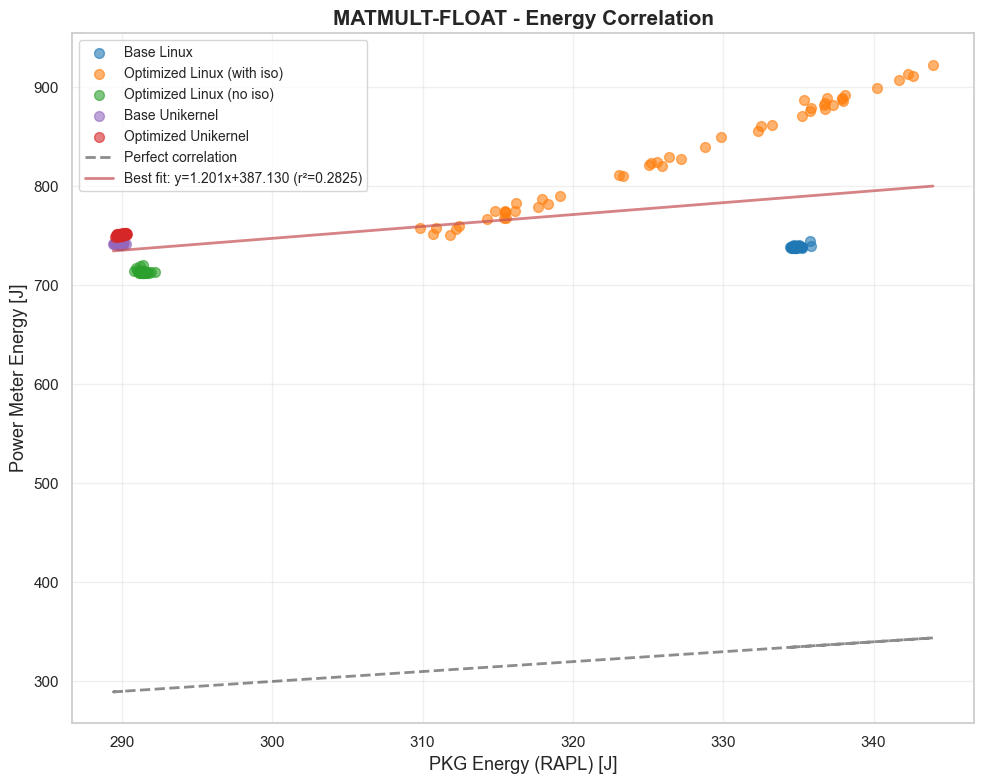

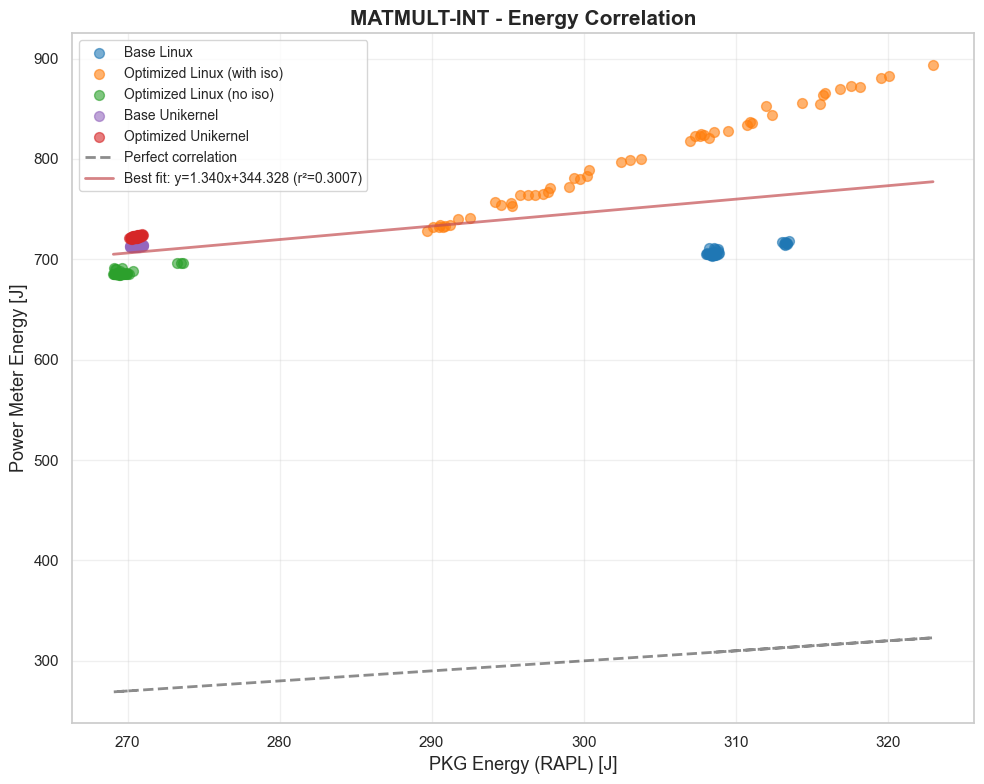

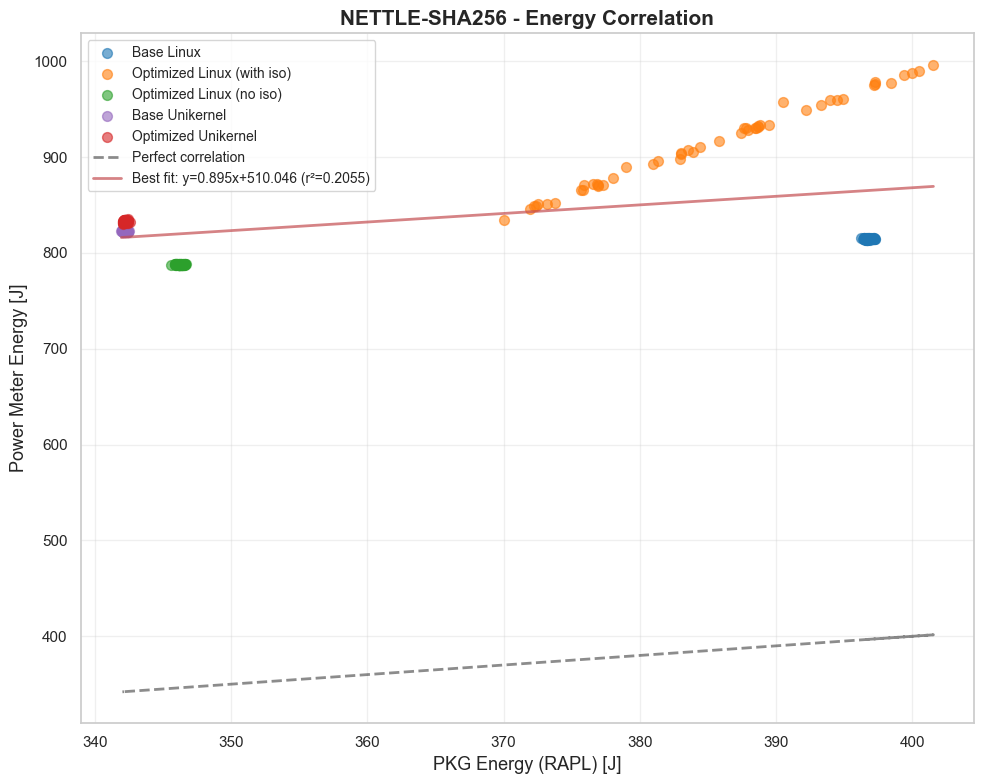

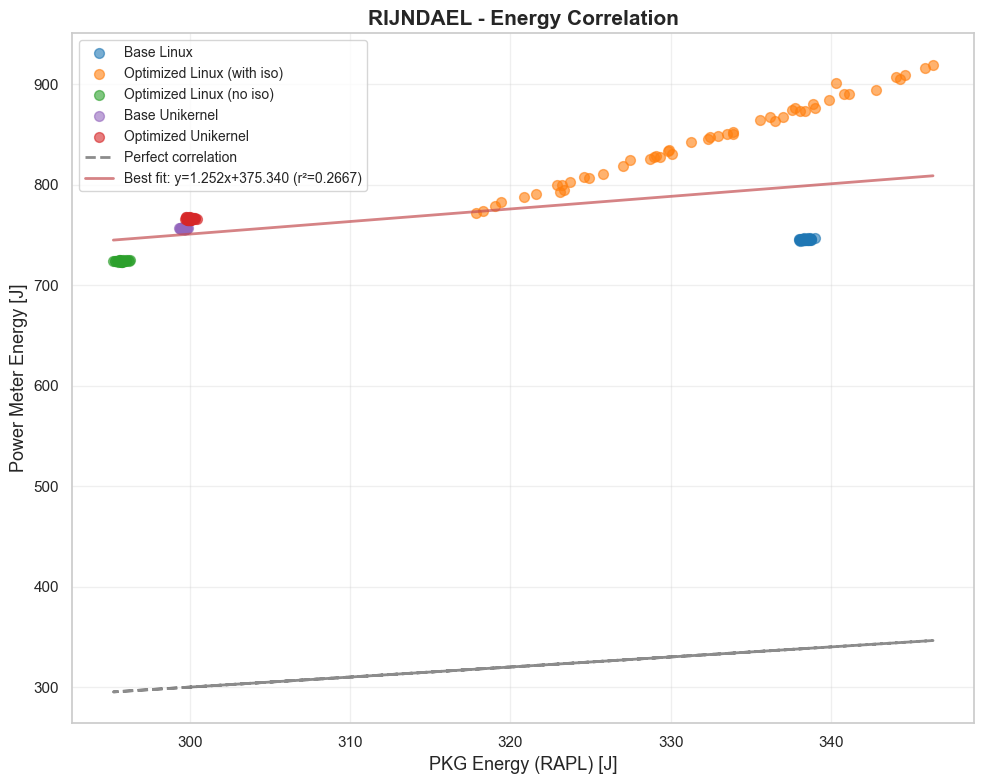

In [19]:
# Scatter plots: PKG Energy vs Power Meter Energy
import matplotlib.pyplot as plt
from scipy import stats

for benchmark in all_benchmarks:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    benchmark_data = energy_comparison[energy_comparison['benchmark'] == benchmark]
    
    for source, color in zip(hue_order, palette[:len(hue_order)]):
        source_data = benchmark_data[benchmark_data['source'] == source]
        
        if len(source_data) > 0:
            ax.scatter(source_data['pkg_energy_J'], 
                      source_data['power_meter_energy_J'],
                      alpha=0.6, s=50, color=color, label=source)
    
    # Add diagonal reference line (perfect correlation) and best fit line
    all_pkg = benchmark_data['pkg_energy_J']
    all_pm = benchmark_data['power_meter_energy_J']
    
    if len(all_pkg) > 0:
        # Get current axis limits
        pkg_range = all_pkg.values
        pm_range = all_pm.values
        
        # Plot perfect correlation line through the data range
        ax.plot(pkg_range, pkg_range, 
               'k--', alpha=0.5, linewidth=2, label='Perfect correlation')
        
        # Add best fit line
        slope, intercept, r_value, p_value, std_err = stats.linregress(all_pkg, all_pm)
        fit_line = slope * all_pkg + intercept
        ax.plot(all_pkg.sort_values(), 
               (slope * all_pkg.sort_values() + intercept),
               'r-', alpha=0.7, linewidth=2, 
               label=f'Best fit: y={slope:.3f}x+{intercept:.3f} (r²={r_value**2:.4f})')
    
    ax.set_xlabel('PKG Energy (RAPL) [J]', fontsize=13)
    ax.set_ylabel('Power Meter Energy [J]', fontsize=13)
    ax.set_title(f'{str(benchmark).upper()} - Energy Correlation', fontsize=15, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'energy_correlation_{benchmark}.png', dpi=150, bbox_inches='tight')
    plt.show()

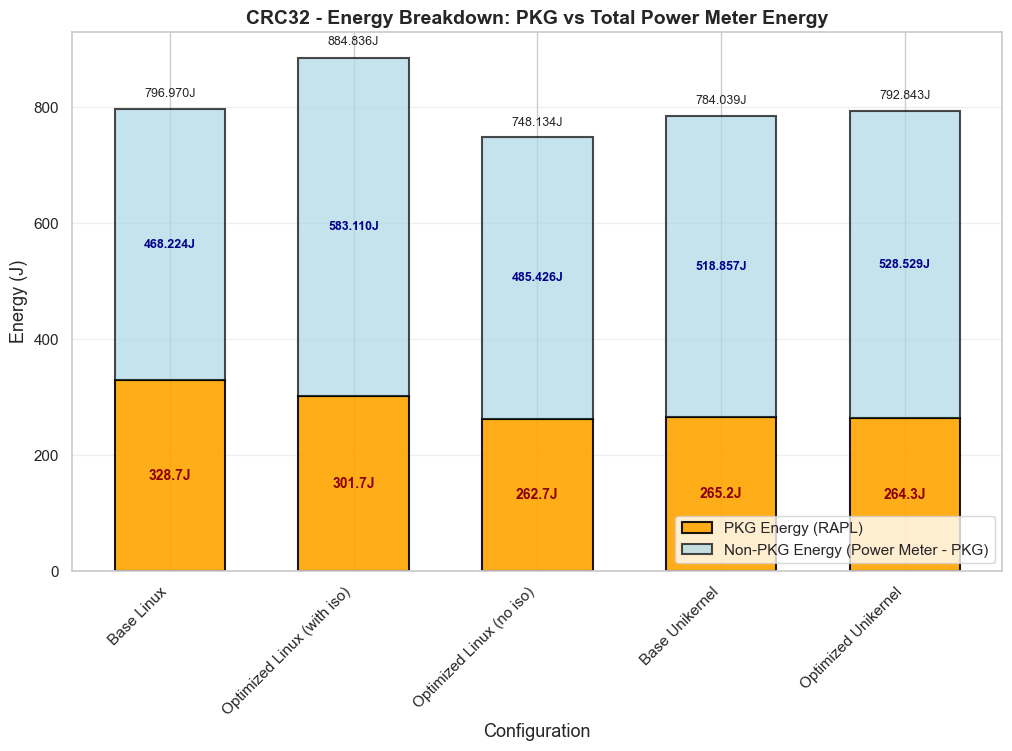

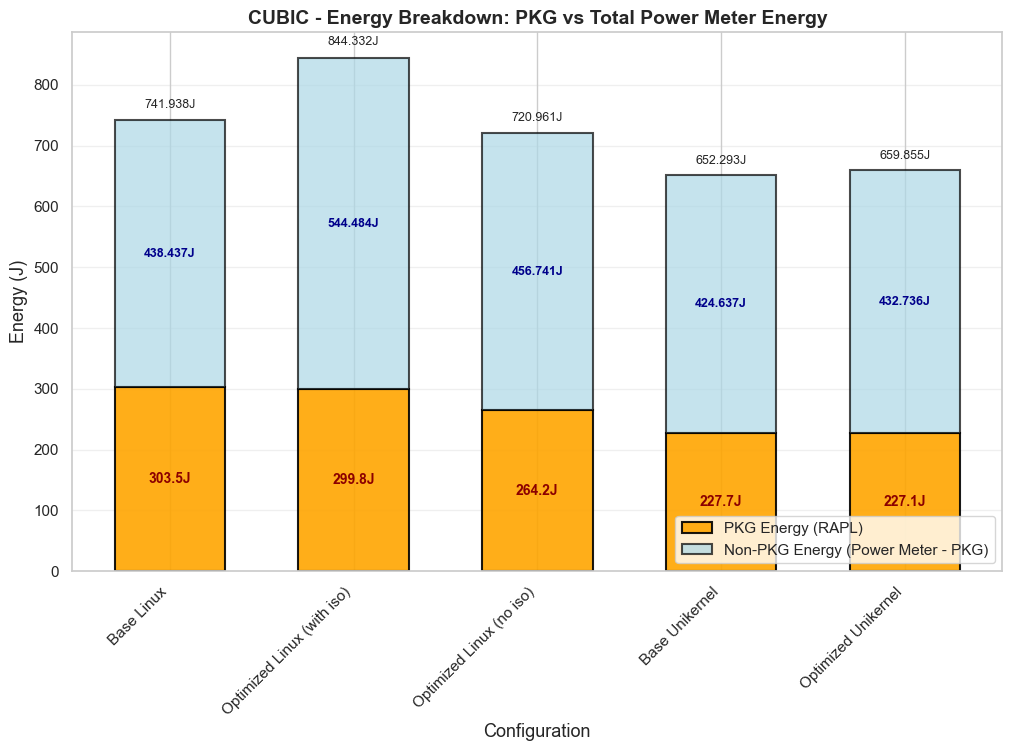

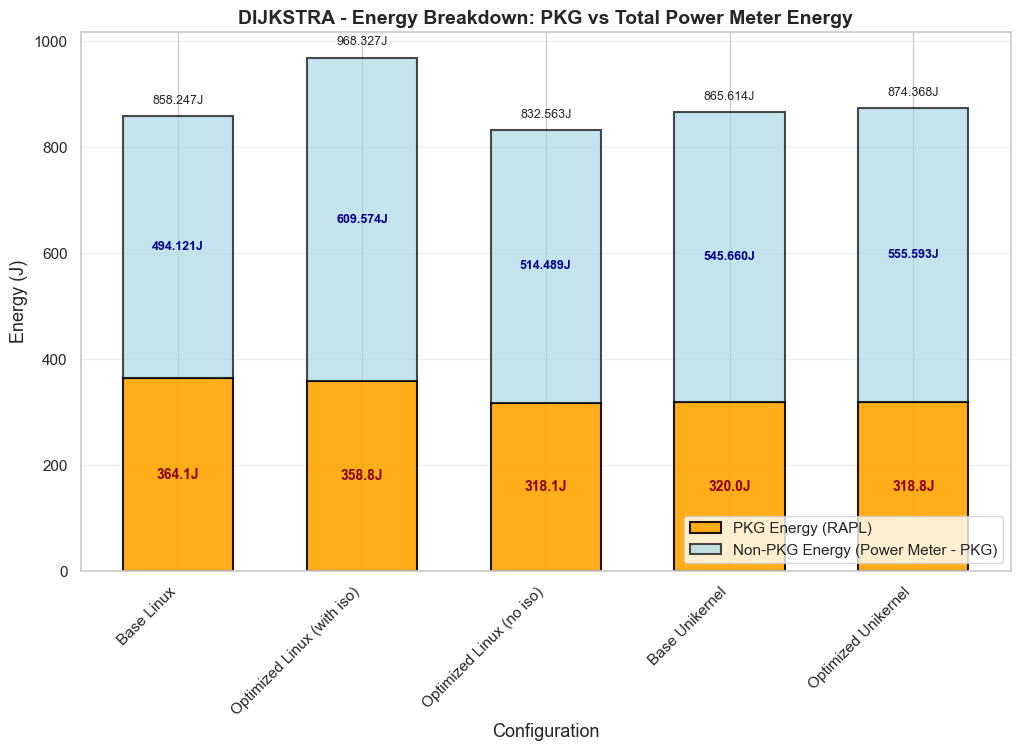

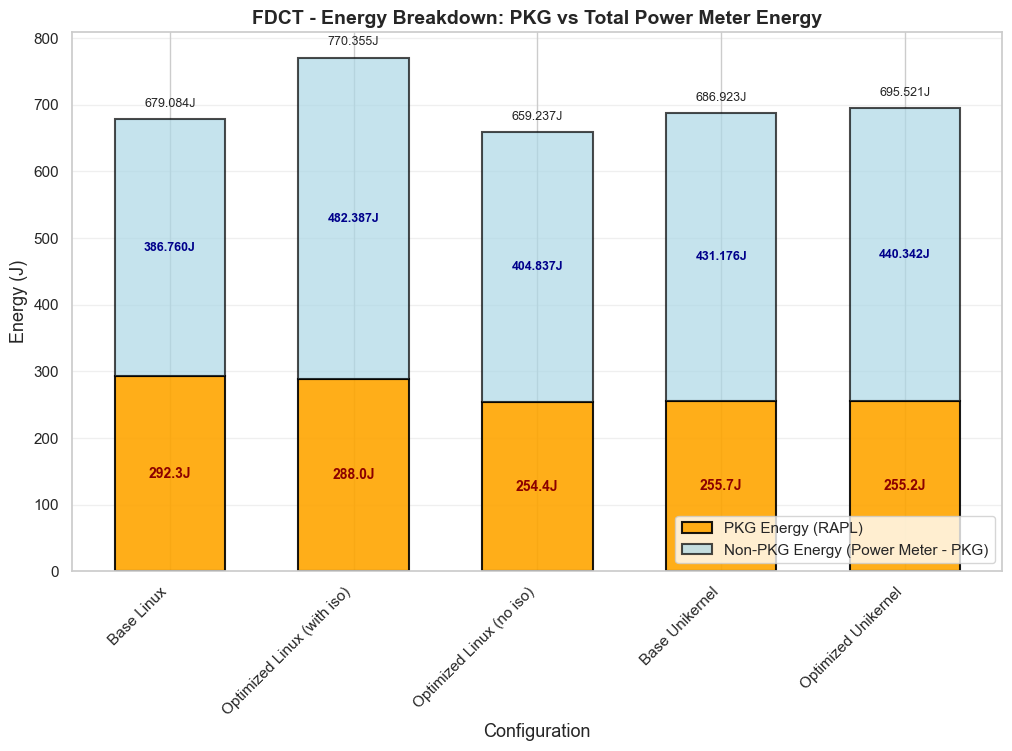

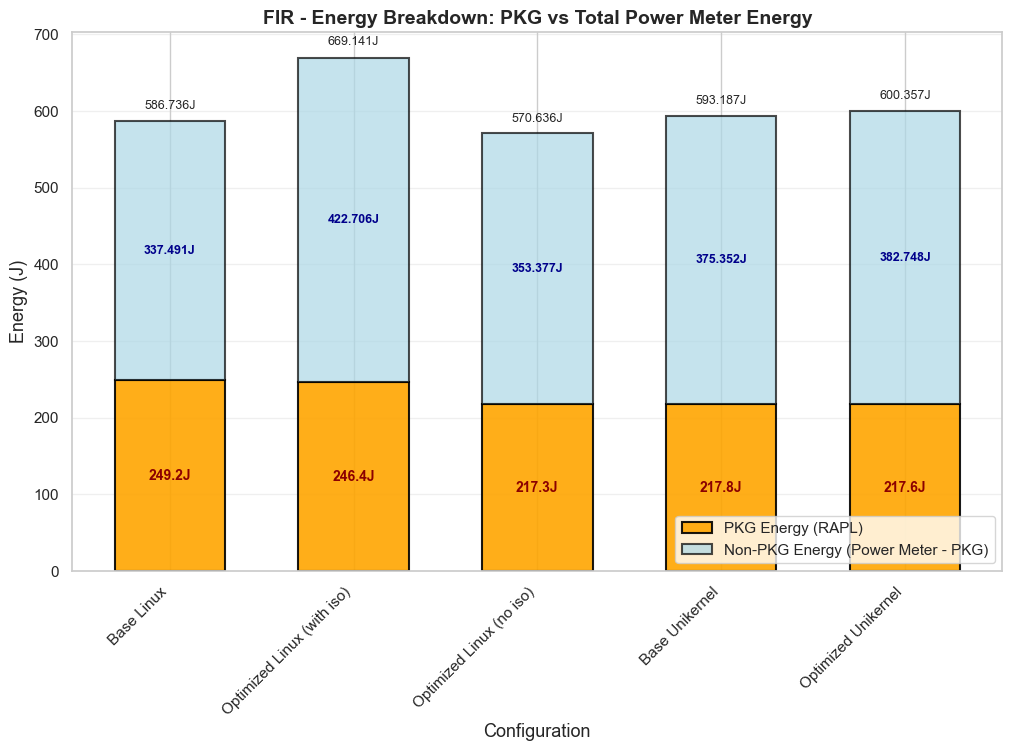

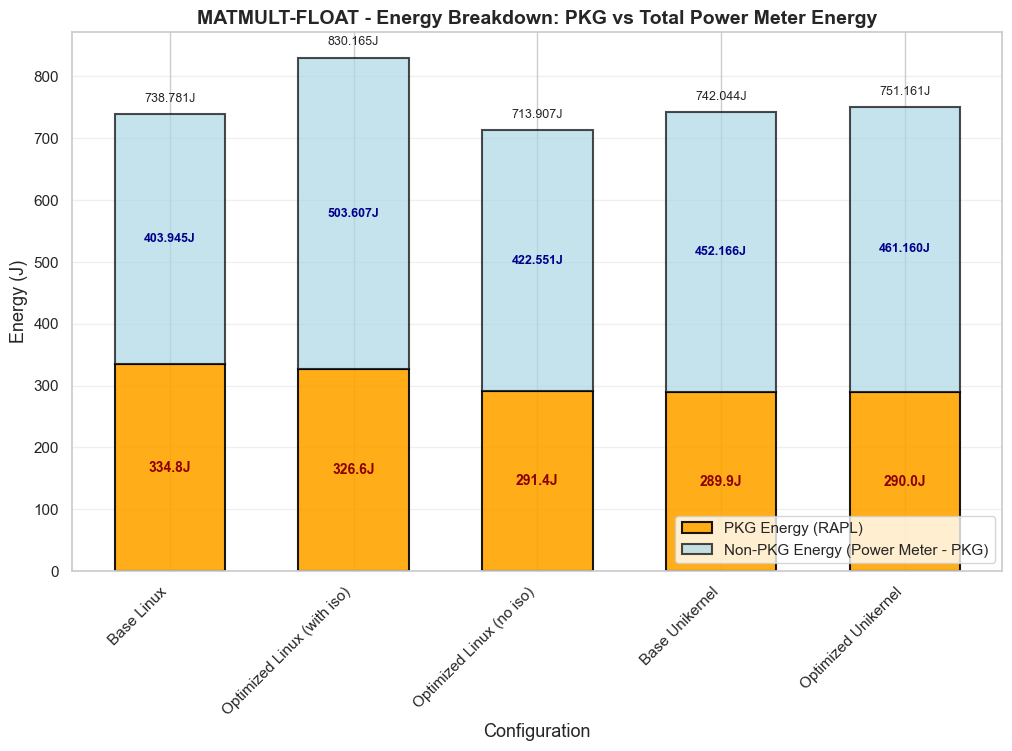

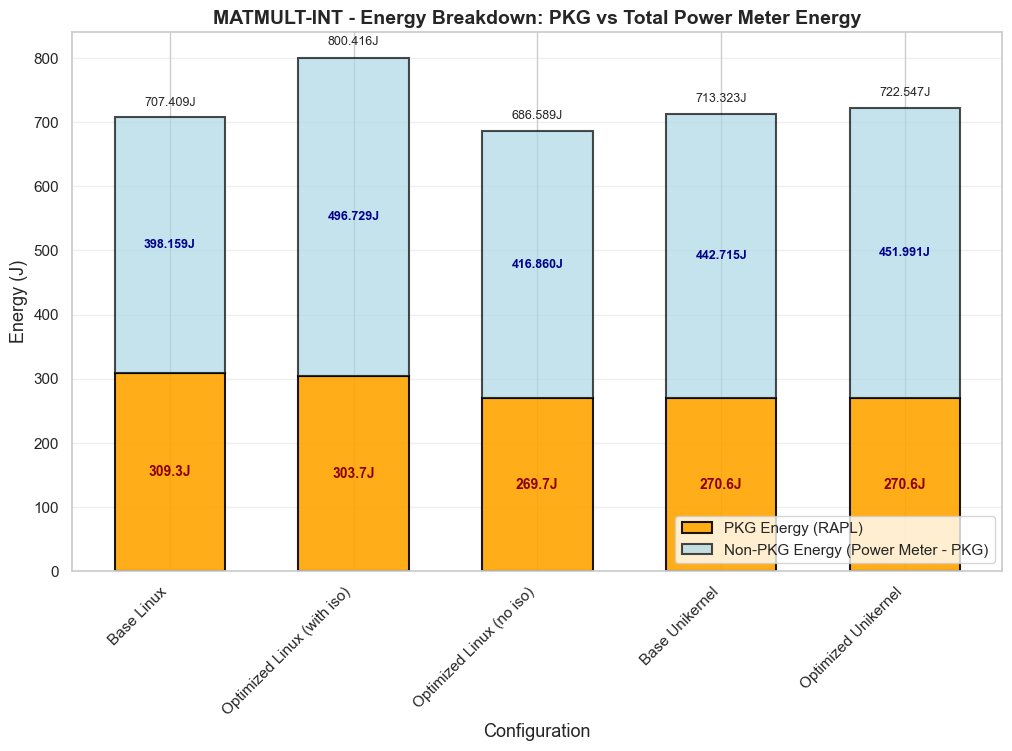

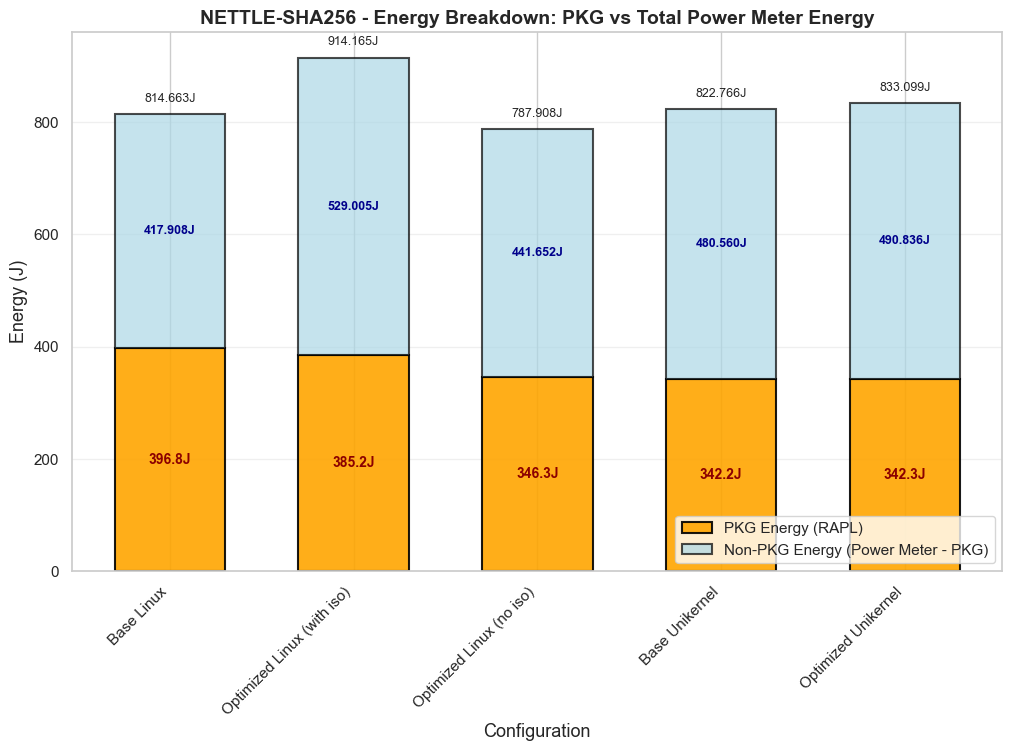

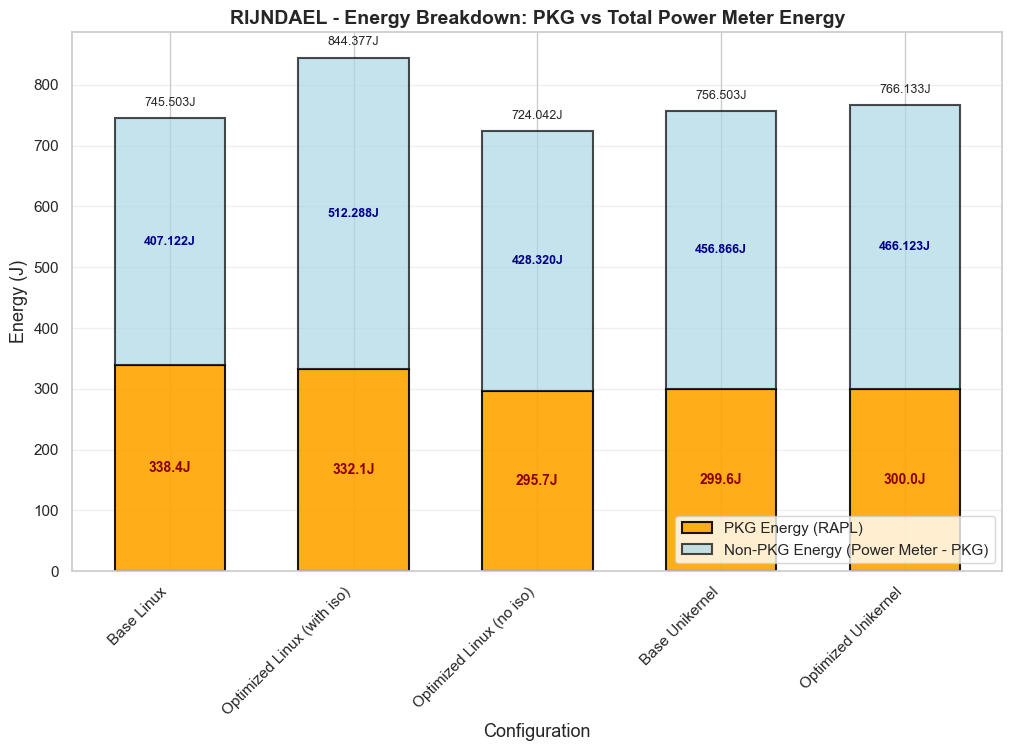

In [20]:
# Stacked barplot: PKG Energy as part of Power Meter Energy
import matplotlib.pyplot as plt
import numpy as np

for benchmark in all_benchmarks:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    benchmark_data = energy_comparison[energy_comparison['benchmark'] == benchmark]
    
    if len(benchmark_data) == 0:
        continue
    
    # Calculate mean values for each configuration
    positions = []
    pkg_means = []
    power_meter_means = []
    labels = []
    
    for i, source in enumerate(hue_order):
        source_data = benchmark_data[benchmark_data['source'] == source]
        
        if len(source_data) > 0:
            positions.append(i)
            pkg_mean = source_data['pkg_energy_J'].mean()
            pm_mean = source_data['power_meter_energy_J'].mean()
            
            pkg_means.append(pkg_mean)
            power_meter_means.append(pm_mean)
            labels.append(source)
    
    # Calculate the remaining energy (non-PKG portion)
    remaining_energy = [pm - pkg for pm, pkg in zip(power_meter_means, pkg_means)]
    
    # Create stacked bar chart
    bar_width = 0.6
    
    # Bottom part: PKG energy
    bars1 = ax.bar(positions, pkg_means, bar_width, 
                   label='PKG Energy (RAPL)', 
                   color='orange', alpha=0.9, edgecolor='black', linewidth=1.5)
    
    # Top part: Remaining energy (Power Meter - PKG)
    bars2 = ax.bar(positions, remaining_energy, bar_width,
                   bottom=pkg_means,
                   label='Non-PKG Energy (Power Meter - PKG)',
                   color='lightblue', alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for i, (pos, pkg, pm, remaining) in enumerate(zip(positions, pkg_means, power_meter_means, remaining_energy)):
        # PKG abselute
        ax.text(pos, pkg / 2, f'{pkg:.1f}J', 
                    ha='center', va='center', fontsize=10, fontweight='bold', color='darkred')
        # Non-PKG energy (absolute value)
        ax.text(pos, pkg + remaining / 2, f'{remaining:.3f}J', 
               ha='center', va='center', fontsize=9, fontweight='bold', color='darkblue')
        # Total energy on top
        ax.text(pos, pm + pm*0.02, f'{pm:.3f}J', 
               ha='center', va='bottom', fontsize=9)
    
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_xlabel('Configuration', fontsize=13)
    ax.set_ylabel('Energy (J)', fontsize=13)
    ax.set_title(f'{str(benchmark).upper()} - Energy Breakdown: PKG vs Total Power Meter Energy', 
                fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    # plt.tight_layout()
    plt.savefig(f'energy_comparison_barplot_{benchmark}.png', dpi=150, bbox_inches='tight')
    plt.show()

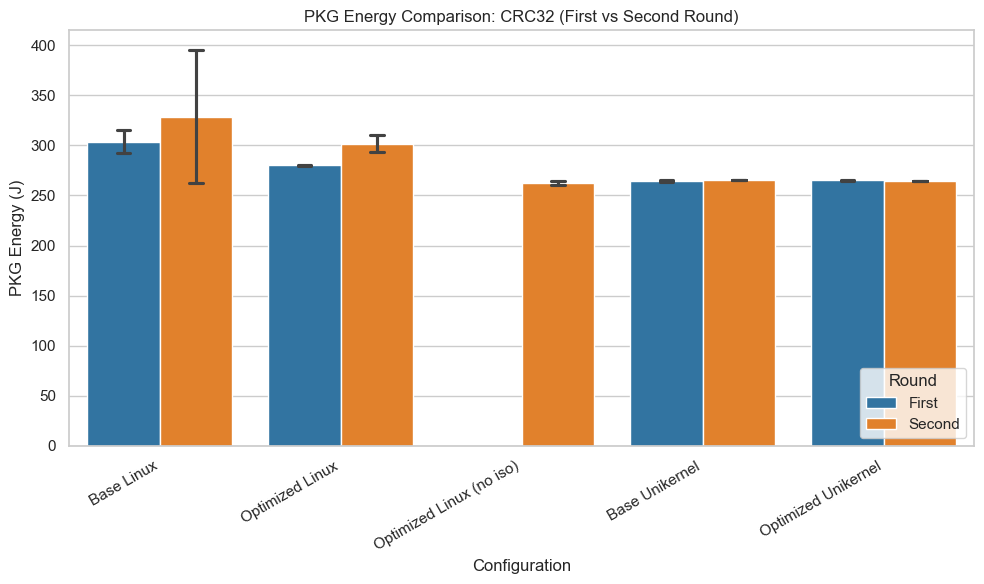

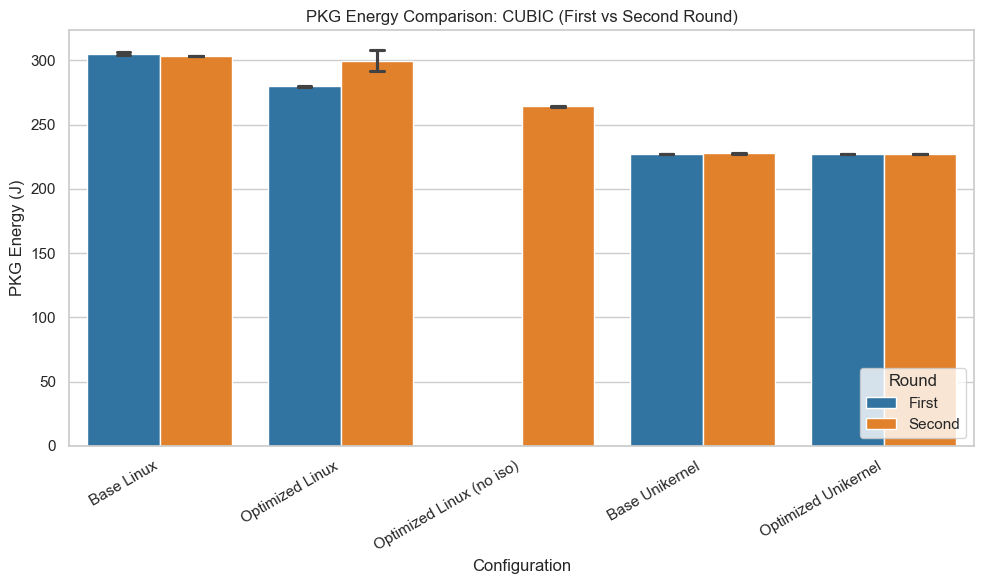

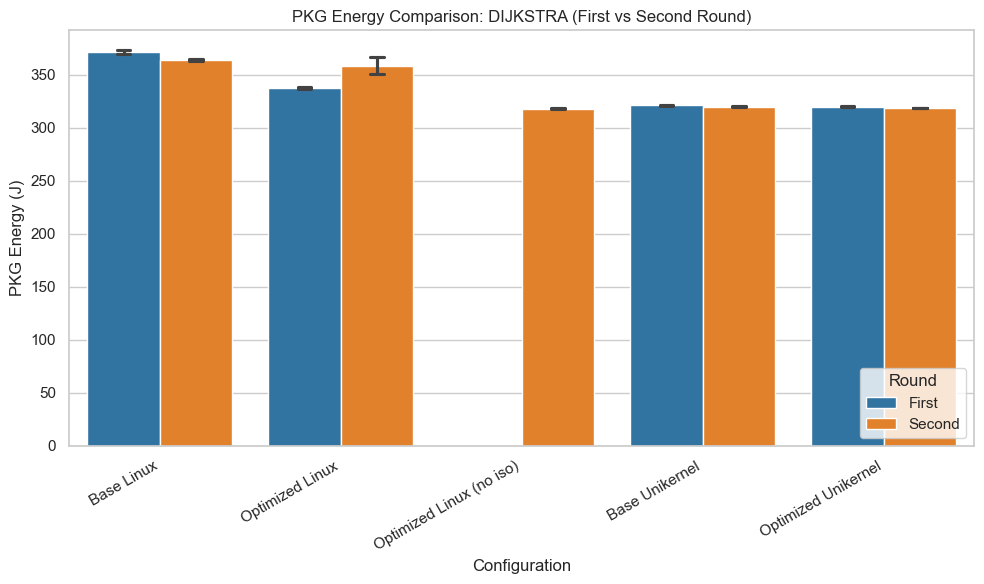

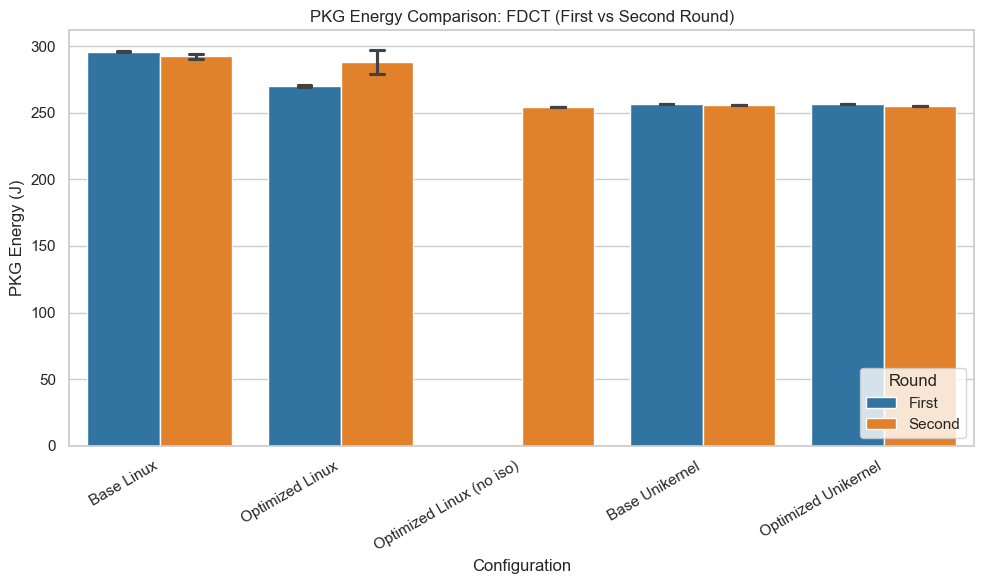

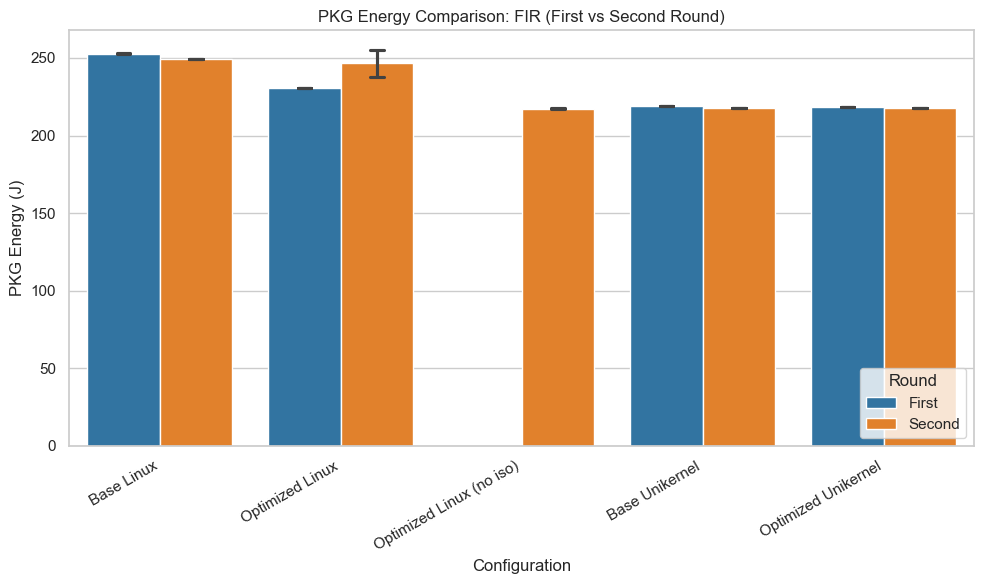

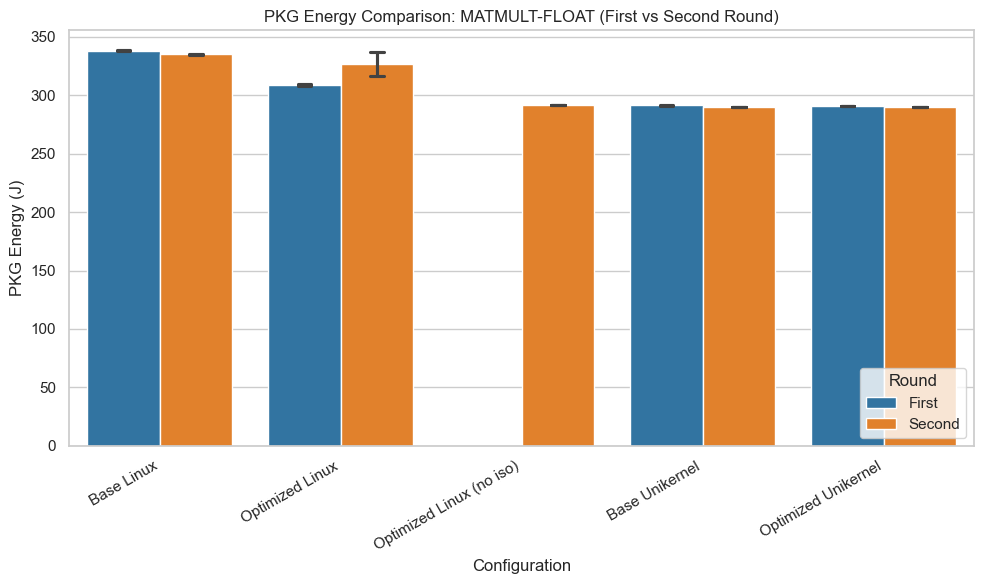

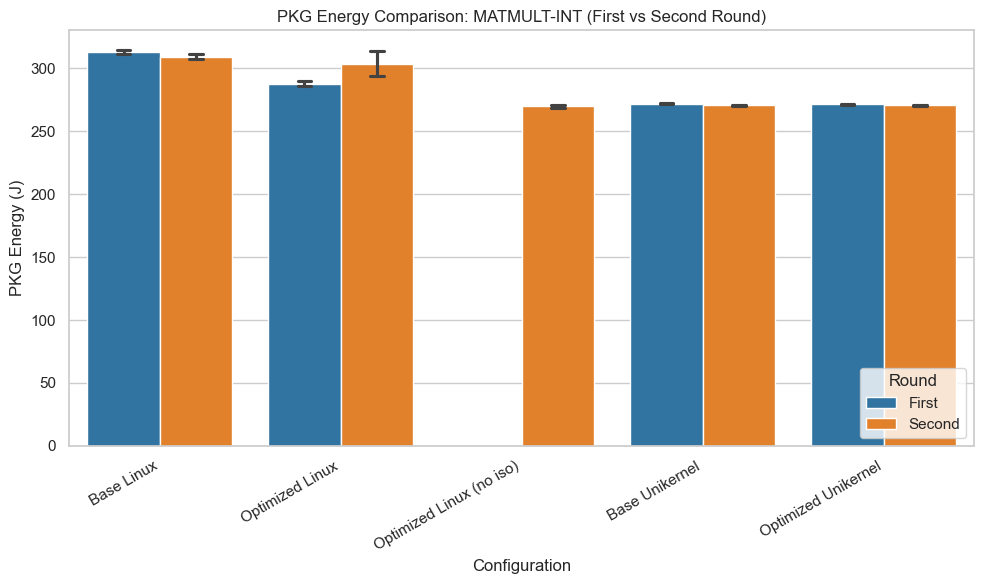

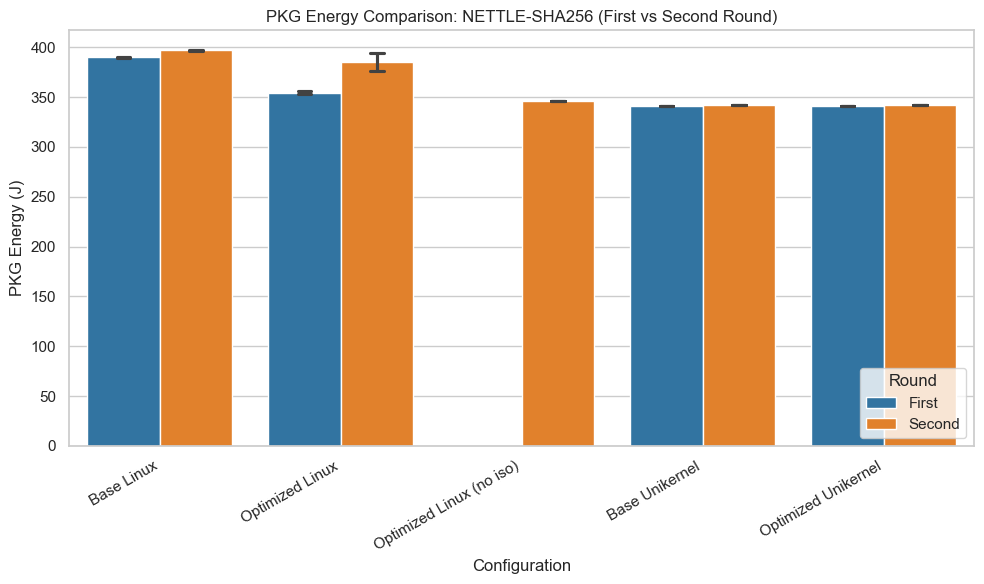

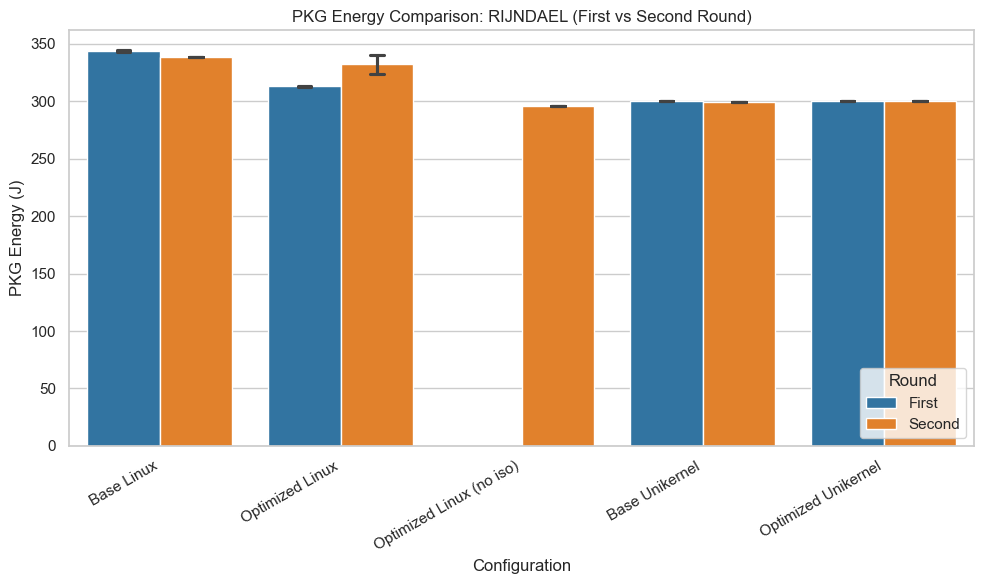

In [ ]:
# Prepare data for overlap comparison
def extract_round_and_config(source):
    if '(first)' in source:
        return 'First', source.replace(' (first)', '')
    elif '(second)' in source:
        # Rename "Optimized Linux (with iso)" to "Optimized Linux"
        config = source.replace(' (second)', '')
        if config == 'Optimized Linux (with iso)':
            config = 'Optimized Linux'
        return 'Second', config
    else:
        return 'Unknown', source

# Load real_first data for PKG energy
real_first_dir = Path('real_first')
real_first_files = {
    'Base Linux (first)': real_first_dir / 'base_linux.csv',
    'Base Unikernel (first)': real_first_dir / 'base_unikernel.csv',
    'Optimized Linux (first)': real_first_dir / 'optimized_linux.csv',
    'Optimized Unikernel (first)': real_first_dir / 'optimized_unikernel.csv',
}

first_pkg_dfs = []
for name, path in real_first_files.items():
    if path.exists():
        df = pd.read_csv(path)
        df['source'] = name
        if 'benchmark' not in df.columns:
            df['benchmark'] = 'all'
        first_pkg_dfs.append(df[['benchmark', 'source', 'pkg_joules']])

real_first_pkg = pd.concat(first_pkg_dfs, ignore_index=True)

# Prepare real_second data
real_second_pkg = all_data[['benchmark', 'source', 'pkg_joules']].copy()
real_second_pkg['source'] = real_second_pkg['source'] + " (second)"

# Combine both datasets
combined_pkg = pd.concat([real_first_pkg, real_second_pkg], ignore_index=True)

overlap_df = combined_pkg.copy()
overlap_df[['Round', 'Configuration']] = overlap_df['source'].apply(
    lambda s: pd.Series(extract_round_and_config(s))
)

# Set the order for configurations (adjust as needed)
order = [
    'Base Linux',
    'Optimized Linux',
    'Optimized Linux (no iso)',
    'Base Unikernel',
    'Optimized Unikernel'
]
order = [label for label in order if label in overlap_df['Configuration'].unique()]

# Plot: Overlapped/grouped barplot for each benchmark
for benchmark in overlap_df['benchmark'].unique():
    plt.figure(figsize=(10, 6))
    data = overlap_df[overlap_df['benchmark'] == benchmark]
    sns.barplot(
        data=data,
        x='Configuration',
        y='pkg_joules',
        hue='Round',
        order=order,
        palette=['#1f77b4', '#ff7f0e'],
        capsize=0.15,
        errorbar='sd'
    )
    plt.title(f'PKG Energy Comparison: {benchmark.upper()} (First vs Second Round)')
    plt.xlabel('Configuration')
    plt.ylabel('PKG Energy (J)')
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Round', loc='lower right')
    plt.tight_layout()
    plt.savefig(f'overlap_pkg_energy_{benchmark}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# CV Overlap Comparison: First vs Second Round
# First, we need to load real_first data and calculate CV for it

# Load real_first data
real_first_dir = Path('real_first')
real_first_files = {
    'Base Linux (first)': real_first_dir / 'base_linux.csv',
    'Base Unikernel (first)': real_first_dir / 'base_unikernel.csv',
    'Optimized Linux (first)': real_first_dir / 'optimized_linux.csv',
    'Optimized Unikernel (first)': real_first_dir / 'optimized_unikernel.csv',
}

first_dfs = []
for name, path in real_first_files.items():
    if path.exists():
        df = pd.read_csv(path)
        df['source'] = name
        if 'benchmark' not in df.columns:
            df['benchmark'] = 'all'
        first_dfs.append(df[['benchmark', 'source', 'pkg_joules']])
    else:
        print(f"Warning: {path} not found")

real_first_data = pd.concat(first_dfs, ignore_index=True)

# Prepare real_second data
real_second_data = all_data[['benchmark', 'source', 'pkg_joules']].copy()
real_second_data['source'] = real_second_data['source'] + " (second)"

# Combine both datasets
combined_cv_data = pd.concat([real_first_data, real_second_data], ignore_index=True)

# Calculate CV for each (source, benchmark) combination
cv_combined = []
for source in combined_cv_data['source'].unique():
    for benchmark in combined_cv_data['benchmark'].unique():
        data = combined_cv_data[(combined_cv_data['source'] == source) & 
                                (combined_cv_data['benchmark'] == benchmark)]['pkg_joules']
        if len(data) > 0:
            mean = data.mean()
            std = data.std()
            cv = (std / mean * 100) if mean != 0 else np.nan
            cv_combined.append({
                'source': source,
                'benchmark': benchmark,
                'cv': cv
            })

cv_combined_df = pd.DataFrame(cv_combined)

# Extract round and configuration
def extract_round_and_config_cv(source):
    if '(first)' in source:
        return 'First', source.replace(' (first)', '')
    elif '(second)' in source:
        config = source.replace(' (second)', '')
        if config == 'Optimized Linux (with iso)':
            config = 'Optimized Linux'
        return 'Second', config
    else:
        return 'Unknown', source

cv_combined_df[['Round', 'Configuration']] = cv_combined_df['source'].apply(
    lambda s: pd.Series(extract_round_and_config_cv(s))
)

# Set the order for configurations (only show optimized linux no iso and unikernels)
order = [
    'Optimized Linux (no iso)',
    'Base Unikernel',
    'Optimized Unikernel'
]
order = [label for label in order if label in cv_combined_df['Configuration'].unique()]

# Plot: CV comparison for each benchmark
for benchmark in cv_combined_df['benchmark'].unique():
    plt.figure(figsize=(10, 6))
    data = cv_combined_df[cv_combined_df['benchmark'] == benchmark]
    sns.barplot(
        data=data,
        x='Configuration',
        y='cv',
        hue='Round',
        order=order,
        palette=['#1f77b4', '#ff7f0e'],
        capsize=0.15,
        errorbar='sd'
    )
    plt.title(f'Coefficient of Variation: {benchmark.upper()} (First vs Second Round)')
    plt.xlabel('Configuration')
    plt.ylabel('Coefficient of Variation (%)')
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Round')
    plt.tight_layout()
    plt.savefig(f'cv_overlap_{benchmark}.png', dpi=150, bbox_inches='tight')
    plt.show()

NameError: name 'Path' is not defined